# Giai đoạn 8 — Huấn luyện XGBoost 2 tầng và Đánh giá

## Kiến trúc hệ thống

```
                    Học sinh nhập: 10 câu Likert + điểm thi + tổ hợp + giới tính + mục tiêu
                                              │
                              ┌───────────────┴───────────────┐
                              ▼                               ▼
                    ┌───────────────────┐         ┌───────────────────┐
                    │  TẦNG 1           │         │  TẦNG 2           │
                    │  XGBoost 7 lớp    │         │  XGBoost 39 lớp   │
                    │  → khối ngành     │         │  → ngành chi tiết │
                    └─────────┬─────────┘         └─────────┬─────────┘
                              │  P₁(khối)                   │  P₂(ngành)
                              └───────────┬─────────────────┘
                                          ▼
                          P(ngành) ∝ P₂(ngành) × P₁(khối của ngành)^β
                                          │
                                          ▼
                                   Top-3 / Top-5 ngành gợi ý
```

**Cả hai tầng dùng chung bộ đặc trưng gốc** (Giai đoạn 7), không tầng nào nhìn thấy nhãn khối ngành.
Cấu trúc phân cấp chỉ áp dụng lúc suy diễn qua phép nhân xác suất, nên **rò rỉ bằng 0** và
**lúc huấn luyện khớp hoàn toàn với lúc phục vụ**.

## Hai chế độ sử dụng

| Chế độ | Người dùng nhập | Ý nghĩa chỉ số |
|---|---|---|
| **Tự động** | Chỉ Likert + điểm thi | ✅ **Năng lực thật của hệ thống** — dùng làm số chính |
| **Tư vấn** | Thêm khối ngành mong muốn | ⚠️ Chỉ số **có điều kiện** — giả định người dùng đã chọn đúng khối |

## Quy trình đánh giá

```
574 dòng thật ──► 15 fold (5 × 3)
                    VAL   = dòng thật của fold          ← mọi chỉ số đo tại đây
                    TRAIN = dòng thật còn lại
                          + 13.796 dòng tổng hợp CỦA RIÊNG fold đó

102 dòng thật ──► TEST — mở đúng MỘT lần, ở cuối notebook này
```

Các bước: **baseline → tìm siêu tham số → so sánh kiến trúc → kiểm tra overfit → ablation →
huấn luyện mô hình cuối → đánh giá test**.

In [1]:
import pandas as pd
import numpy as np
import json
import time
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)

# ── Thiết lập kiểu biểu đồ dùng chung cho toàn bộ báo cáo ────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

# Bảng màu thống nhất
C_THAT  = "#D64550"   # dữ liệu thật
C_GA    = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH  = "#3B7DD8"   # nhấn mạnh chính
C_CAM   = "#E8873A"   # nhấn mạnh phụ
C_TIM   = "#8E5FBF"
C_XAM   = "#AEB6BF"   # nền / mốc so sánh
C_DAM   = "#2C3E50"
C_KHOI  = ["#3B7DD8", "#E8873A", "#8E5FBF", "#19A2A2", "#D64550", "#C9A227", "#5D6D7E"]


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    # Ghi số ở cuối mỗi thanh ngang
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    # Ghi số trên đầu mỗi cột dọc
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    # Dòng chú giải nằm dưới hình — nêu kết luận rút ra từ biểu đồ.
    # Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    # dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai
    # bên đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def luu(fig, thu_muc, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(thu_muc / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 Đã lưu hình: {ten}")

MR_DIR     = Path("../data/processed/07_model_ready")
SPLIT_DIR  = Path("../data/processed/02_split")
SYNTH_DIR  = Path("../data/processed/04_synthetic")
OUTPUT_DIR = Path("../data/processed/08_model")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

X_train = pd.read_csv(MR_DIR / "X_train.csv")
X_test  = pd.read_csv(MR_DIR / "X_test.csv")
y_tr_n  = pd.read_csv(MR_DIR / "y_train_nganh.csv")["target_nganh"].to_numpy()
y_te_n  = pd.read_csv(MR_DIR / "y_test_nganh.csv")["target_nganh"].to_numpy()
y_tr_k  = pd.read_csv(MR_DIR / "y_train_khoi.csv")["target_khoi"].to_numpy()
y_te_k  = pd.read_csv(MR_DIR / "y_test_khoi.csv")["target_khoi"].to_numpy()
w_tr    = pd.read_csv(MR_DIR / "w_train.csv")["sample_weight"].to_numpy()
is_real = pd.read_csv(MR_DIR / "is_real_train.csv")["is_real"].to_numpy()
M       = np.load(MR_DIR / "M_nganh_khoi.npy")

Z  = np.load(SYNTH_DIR / "synthetic_per_fold.npz")
CV = json.load(open(SPLIT_DIR / "cv_folds_real.json", encoding="utf-8"))
LB = json.load(open(MR_DIR / "label_encoder_mapping.json", encoding="utf-8"))
FN = json.load(open(MR_DIR / "feature_names.json", encoding="utf-8"))

TEN_NGANH   = [LB["idx_to_name"][str(i)] for i in range(39)]
TEN_KHOI    = [LB["khoi_to_name"][str(i)] for i in range(7)]
LIKERT_COLS = FN["likert_cols"]

N_REAL = int(is_real.sum())
assert is_real[:N_REAL].all() and not is_real[N_REAL:].any(), "Dòng thật phải nằm ở đầu X_train"
X_syn_base = X_train.iloc[N_REAL:].reset_index(drop=True)
folds_all = CV["folds"]
folds_tim = [f for f in folds_all if f["repeat"] == 0]

print(f"Train : {len(X_train):,} dòng  ({N_REAL} thật + {len(X_syn_base):,} tổng hợp), "
      f"{X_train.shape[1]} đặc trưng")
print(f"Test  : {len(X_test)} dòng thật")
print(f"CV    : {len(folds_all)} fold  |  tìm siêu tham số trên {len(folds_tim)} fold")

Train : 14,370 dòng  (574 thật + 13,796 tổng hợp), 43 đặc trưng
Test  : 102 dòng thật
CV    : 15 fold  |  tìm siêu tham số trên 5 fold


## 1. Bộ khung Cross-Validation và các hàm đo

In [2]:
def lap_fold(f, dung_tong_hop=True):
    # Dựng dữ liệu một fold. VAL chỉ gồm dòng THẬT; dòng tổng hợp chỉ vào TRAIN
    # và là bộ sinh riêng cho fold này (phân phối học từ TRAIN của fold).
    tr, va = np.asarray(f["train_idx"]), np.asarray(f["val_idx"])
    pX, pk, pn, pw = [X_train.iloc[tr]], [y_tr_k[tr]], [y_tr_n[tr]], [w_tr[tr]]
    if dung_tong_hop:
        fid = f["fold"]
        Xs = X_syn_base.copy()
        Xs[LIKERT_COLS]    = Z[f"likert_{fid}"].astype(int)
        Xs["gioi_tinh_ma"] = Z[f"gioi_{fid}"].astype(int)
        Xs["muc_tieu_ma"]  = Z[f"muctieu_{fid}"].astype(int)
        pX.append(Xs); pk.append(y_tr_k[N_REAL:]); pn.append(y_tr_n[N_REAL:]); pw.append(w_tr[N_REAL:])
    return (pd.concat(pX, ignore_index=True), np.concatenate(pk), np.concatenate(pn),
            np.concatenate(pw), X_train.iloc[va], y_tr_k[va], y_tr_n[va])


def topk(y, P, k):
    return float(np.mean([y[i] in np.argpartition(-P[i], k)[:k] for i in range(len(y))]))


def do_luong(y, P, ks=(1, 3, 5)):
    pred = P.argmax(1)
    m = {f"top{k}": topk(y, P, k) for k in ks}
    m["macro_f1"] = float(f1_score(y, pred, average="macro", zero_division=0))
    m["balanced_acc"] = float(balanced_accuracy_score(y, pred))
    return m


def fit_xgb(params, X, y, w, n_class, Xv=None, yv=None):
    p = dict(objective="multi:softprob", num_class=n_class, eval_metric="mlogloss",
             tree_method="hist", random_state=SEED, verbosity=0, n_jobs=-1, **params)
    if Xv is not None:
        p["early_stopping_rounds"] = 40
    m = XGBClassifier(**p)
    m.fit(X, y, sample_weight=w, eval_set=[(Xv, yv)] if Xv is not None else None, verbose=False)
    return m


def chay_cv(ps1, ps2, folds, dung_tong_hop=True):
    # Lưu lại xác suất dự đoán trên VAL để đánh giá nhiều kiến trúc mà không phải train lại
    out = []
    for f in folds:
        Xtr, ytk, ytn, wt, Xva, yvk, yvn = lap_fold(f, dung_tong_hop)
        m1 = fit_xgb(ps1, Xtr, ytk, wt, 7,  Xva, yvk)
        m2 = fit_xgb(ps2, Xtr, ytn, wt, 39, Xva, yvn)
        n_that_tr = len(f["train_idx"])
        out.append({"fold": f["fold"], "P1": m1.predict_proba(Xva), "P2": m2.predict_proba(Xva),
                    "yk": yvk, "yn": yvn,
                    "P2_train": m2.predict_proba(Xtr.iloc[:n_that_tr]),
                    "yn_train": ytn[:n_that_tr],
                    "best_iter": (m1.best_iteration, m2.best_iteration)})
    return out


def gop_2_tang(P1, P2, beta=1.0):
    # Nhân xác suất: P(ngành) ∝ P₂(ngành) × P₁(khối của ngành)^β
    P = P2 * np.power(P1 @ M.T, beta)
    return P / P.sum(axis=1, keepdims=True)


def gop_tu_van(P2, khoi_nguoi_dung):
    # Chế độ tư vấn: người dùng cung cấp khối → chỉ giữ các ngành trong khối đó
    P = P2 * M[:, khoi_nguoi_dung].T
    return P / P.sum(axis=1, keepdims=True)

print("✅ Sẵn sàng bộ khung Cross-Validation")

✅ Sẵn sàng bộ khung Cross-Validation


## 2. Baseline — mốc so sánh bắt buộc

Không có baseline thì con số "top-3 = 40%" là vô nghĩa. Hai mốc:
- **Đoán theo lớp đông nhất**: luôn trả về ngành/khối phổ biến nhất trong tập train.
- **Đoán ngẫu nhiên**: `k/39` cho top-k.

In [3]:
rows = []
for f in folds_all:
    yv_n, yv_k = y_tr_n[f["val_idx"]], y_tr_k[f["val_idx"]]
    yt_n, yt_k = y_tr_n[f["train_idx"]], y_tr_k[f["train_idx"]]
    dn = np.bincount(yt_n, minlength=39).astype(float)
    dk = np.bincount(yt_k, minlength=7).astype(float)
    rows.append({**{f"nganh_{k}": v for k, v in
                    do_luong(yv_n, np.tile(dn / dn.sum(), (len(yv_n), 1))).items()},
                 **{f"khoi_{k}": v for k, v in
                    do_luong(yv_k, np.tile(dk / dk.sum(), (len(yv_k), 1)), ks=(1, 2, 3)).items()}})
BASE = pd.DataFrame(rows).mean()

print("BẢNG 8.1 — Baseline (trung bình 15 fold, đo trên dòng thật)\n")
print(f"{'':<30}{'Top-1':>10}{'Top-3':>10}{'Top-5':>10}{'macro-F1':>11}")
print("─" * 71)
print(f"{'Khối ngành — lớp đông nhất':<30}{BASE['khoi_top1']:>9.1%}{'—':>10}{'—':>10}"
      f"{BASE['khoi_macro_f1']:>11.3f}")
print(f"{'Khối ngành — ngẫu nhiên':<30}{1/7:>9.1%}{'—':>10}{'—':>10}{'—':>11}")
print(f"{'Ngành — lớp đông nhất':<30}{BASE['nganh_top1']:>9.1%}{BASE['nganh_top3']:>10.1%}"
      f"{BASE['nganh_top5']:>10.1%}{BASE['nganh_macro_f1']:>11.3f}")
print(f"{'Ngành — ngẫu nhiên':<30}{1/39:>9.1%}{3/39:>10.1%}{5/39:>10.1%}{'—':>11}")
print("─" * 71)

BẢNG 8.1 — Baseline (trung bình 15 fold, đo trên dòng thật)

                                   Top-1     Top-3     Top-5   macro-F1
───────────────────────────────────────────────────────────────────────
Khối ngành — lớp đông nhất        25.4%         —         —      0.058
Khối ngành — ngẫu nhiên           14.3%         —         —          —
Ngành — lớp đông nhất              7.0%     17.4%     25.8%      0.003
Ngành — ngẫu nhiên                 2.6%      7.7%     12.8%          —
───────────────────────────────────────────────────────────────────────


## 3. Tìm siêu tham số bằng random search

Siêu tham số được **chọn bằng validation thật**, không gõ tay. Early stopping tự xác định số cây
thay vì ấn định cứng.

In [4]:
KHONG_GIAN = {
    "max_depth":        [3, 4, 5, 6, 8],
    "learning_rate":    [0.03, 0.05, 0.08, 0.12],
    "n_estimators":     [600],
    "subsample":        [0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 6, 10],
    "reg_alpha":        [0.0, 0.1, 0.5],
    "reg_lambda":       [1.0, 3.0, 10.0],
    "gamma":            [0.0, 0.1, 0.5],
}
N_THU = 14

def boc(r):
    return {k: v[r.integers(len(v))] for k, v in KHONG_GIAN.items()}

def cham_diem(params, n_class, folds):
    d = []
    for f in folds:
        Xtr, ytk, ytn, wt, Xva, yvk, yvn = lap_fold(f)
        yt, yv = (ytk, yvk) if n_class == 7 else (ytn, yvn)
        m = fit_xgb(params, Xtr, yt, wt, n_class, Xva, yv)
        d.append(f1_score(yv, m.predict_proba(Xva).argmax(1), average="macro", zero_division=0))
    return float(np.mean(d))

t0 = time.time()
r = np.random.default_rng(SEED)
tim = {1: [], 2: []}
for tang, nc in [(1, 7), (2, 39)]:
    for _ in range(N_THU):
        p = boc(r)
        tim[tang].append((cham_diem(p, nc, folds_tim), p))
    tim[tang].sort(key=lambda t: -t[0])
    print(f"Tầng {tang} ({nc} lớp) — macro-F1 tốt nhất trên VAL thật: {tim[tang][0][0]:.4f}")

BEST_S1, BEST_S2 = tim[1][0][1], tim[2][0][1]
print(f"\nThử {N_THU} cấu hình mỗi tầng trên {len(folds_tim)} fold — {time.time()-t0:.0f} giây\n")
print("BẢNG 8.2 — Siêu tham số được chọn\n")
print(pd.DataFrame({"Tầng 1 (khối ngành)": BEST_S1, "Tầng 2 (ngành)": BEST_S2}).to_string())

Tầng 1 (7 lớp) — macro-F1 tốt nhất trên VAL thật: 0.4654


Tầng 2 (39 lớp) — macro-F1 tốt nhất trên VAL thật: 0.1345

Thử 14 cấu hình mỗi tầng trên 5 fold — 777 giây

BẢNG 8.2 — Siêu tham số được chọn

                  Tầng 1 (khối ngành)  Tầng 2 (ngành)
max_depth                        6.00            4.00
learning_rate                    0.08            0.03
n_estimators                   600.00          600.00
subsample                        0.80            0.70
colsample_bytree                 1.00            0.60
min_child_weight                 6.00           10.00
reg_alpha                        0.10            0.50
reg_lambda                       3.00           10.00
gamma                            0.00            0.10


   💾 Đã lưu hình: hinh_8_1_tim_sieu_tham_so.png


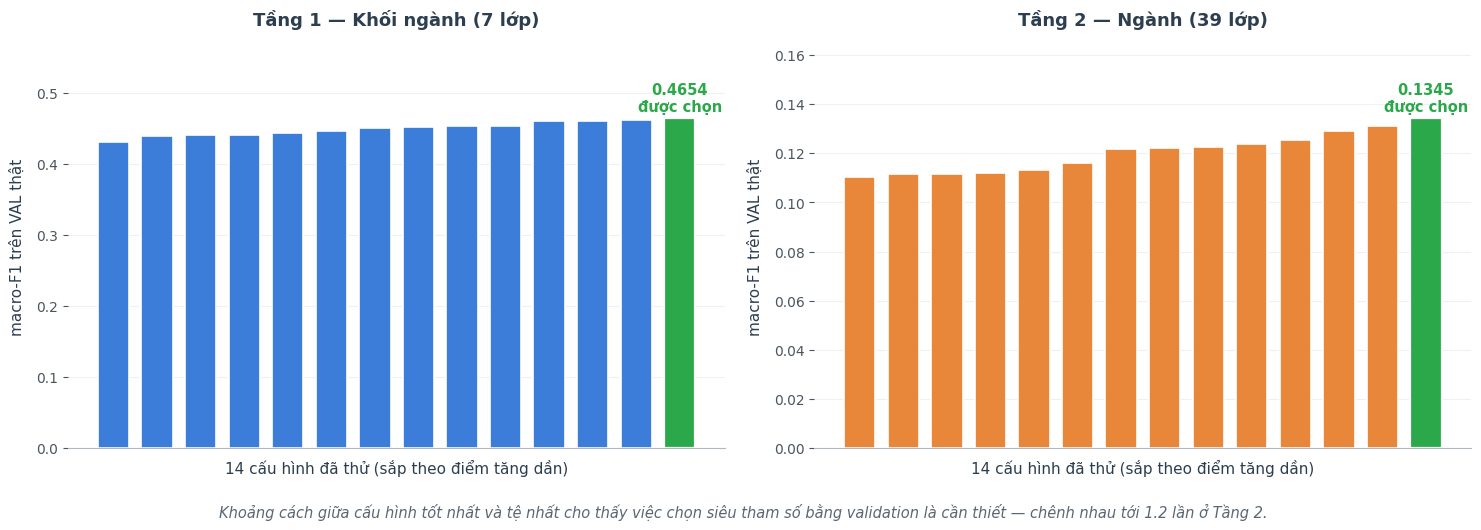

In [5]:
# ═══════════ HÌNH 8.1 — Kết quả tìm siêu tham số ═══════════
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, tang, ten, mau in [(axes[0], 1, "Tầng 1 — Khối ngành (7 lớp)", C_XANH),
                           (axes[1], 2, "Tầng 2 — Ngành (39 lớp)", C_CAM)]:
    diem = sorted([s for s, _ in tim[tang]])
    ax.bar(range(len(diem)), diem, color=mau, edgecolor="white", linewidth=1.2, width=0.72)
    ax.bar([len(diem) - 1], [diem[-1]], color=C_GA, edgecolor="white", linewidth=1.6, width=0.72)
    ax.text(len(diem) - 1, diem[-1] + max(diem) * 0.018, f"{diem[-1]:.4f}\nđược chọn",
            ha="center", fontsize=10.5, fontweight="bold", color=C_GA)
    ax.set_xlabel(f"{N_THU} cấu hình đã thử (sắp theo điểm tăng dần)")
    ax.set_ylabel("macro-F1 trên VAL thật")
    ax.set_ylim(0, max(diem) * 1.22)
    ax.set_title(ten)
    ax.set_xticks([]); ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_8_1_tim_sieu_tham_so.png",
    f"Khoảng cách giữa cấu hình tốt nhất và tệ nhất cho thấy việc chọn siêu tham số bằng validation "
    f"là cần thiết — chênh nhau tới {max(s for s,_ in tim[2])/max(min(s for s,_ in tim[2]), 1e-9):.1f} lần ở Tầng 2.")
plt.show()

## 4. So sánh kiến trúc trên toàn bộ 15 fold

Ba phương án cùng bộ chia dữ liệu, cùng siêu tham số:
1. **Model phẳng 39 lớp** — bỏ qua cấu trúc khối ngành.
2. **2 tầng, nhân xác suất** — $P \propto P_2 \cdot P_1^{\beta}$, với $\beta$ chọn trên validation.
3. **2 tầng, chế độ tư vấn** — người dùng cung cấp khối (chỉ số **có điều kiện**).

In [6]:
t0 = time.time()
CACHE = chay_cv(BEST_S1, BEST_S2, folds_all)
print(f"Đã chạy CV đầy đủ {len(folds_all)} fold trong {time.time()-t0:.0f} giây")

betas = np.arange(0.0, 2.01, 0.1)
diem_beta = [np.mean([f1_score(c["yn"], gop_2_tang(c["P1"], c["P2"], b).argmax(1),
                               average="macro", zero_division=0) for c in CACHE]) for b in betas]
BETA = float(betas[int(np.argmax(diem_beta))])
print(f"β tối ưu (chọn trên VAL thật): {BETA:.1f}    "
      f"[β = 0 nghĩa là bỏ Tầng 1; β = 1 là nhân xác suất đầy đủ]")

def gom(fn):
    return pd.DataFrame([do_luong(c["yn"], fn(c)) for c in CACHE]).agg(["mean", "std"])

KQ_CV = {
    "Đoán lớp đông nhất": pd.DataFrame([{
        "top1": BASE["nganh_top1"], "top3": BASE["nganh_top3"], "top5": BASE["nganh_top5"],
        "macro_f1": BASE["nganh_macro_f1"], "balanced_acc": BASE["nganh_balanced_acc"]}]).agg(["mean", "std"]),
    "Model phẳng 39 lớp": gom(lambda c: c["P2"]),
    f"2 tầng — nhân xác suất (β={BETA:.1f})": gom(lambda c: gop_2_tang(c["P1"], c["P2"], BETA)),
    "2 tầng — tư vấn (có điều kiện)": gom(lambda c: gop_tu_van(c["P2"], c["yk"])),
}
bang_cv = pd.DataFrame({k: v.loc["mean"] for k, v in KQ_CV.items()}).T
bang_sd = pd.DataFrame({k: v.loc["std"]  for k, v in KQ_CV.items()}).T

print("\nBẢNG 8.3 — Kết quả Cross-Validation (trung bình 15 fold, chỉ đo trên dòng THẬT)\n")
print(f"{'Phương án':<42}{'Top-1':>9}{'Top-3':>9}{'Top-5':>9}{'macro-F1':>11}{'bal-acc':>10}")
print("─" * 90)
for k in bang_cv.index:
    b = bang_cv.loc[k]
    print(f"{k:<42}{b.top1:>8.1%}{b.top3:>9.1%}{b.top5:>9.1%}{b.macro_f1:>11.3f}{b.balanced_acc:>10.3f}")
print("─" * 90)

Đã chạy CV đầy đủ 15 fold trong 223 giây
β tối ưu (chọn trên VAL thật): 0.6    [β = 0 nghĩa là bỏ Tầng 1; β = 1 là nhân xác suất đầy đủ]



BẢNG 8.3 — Kết quả Cross-Validation (trung bình 15 fold, chỉ đo trên dòng THẬT)

Phương án                                     Top-1    Top-3    Top-5   macro-F1   bal-acc
──────────────────────────────────────────────────────────────────────────────────────────
Đoán lớp đông nhất                            7.0%    17.4%    25.8%      0.003     0.026
Model phẳng 39 lớp                           16.9%    36.1%    47.6%      0.125     0.142
2 tầng — nhân xác suất (β=0.6)               18.1%    36.9%    49.5%      0.137     0.151
2 tầng — tư vấn (có điều kiện)               34.4%    68.9%    85.0%      0.266     0.289
──────────────────────────────────────────────────────────────────────────────────────────


In [7]:
# Tầng 1 riêng + kiểm tra overfit
M1 = pd.DataFrame([do_luong(c["yk"], c["P1"], ks=(1, 2, 3)) for c in CACHE]).mean()
acc_tr = np.mean([(c["yn_train"] == c["P2_train"].argmax(1)).mean() for c in CACHE])
acc_va = np.mean([(c["yn"] == c["P2"].argmax(1)).mean() for c in CACHE])

print(f"TẦNG 1 — Khối ngành (CV trên dòng thật):")
print(f"   Top-1 = {M1.top1:.1%}   Top-2 = {M1.top2:.1%}   Top-3 = {M1.top3:.1%}   "
      f"macro-F1 = {M1.macro_f1:.3f}")
print(f"   (baseline lớp đông nhất {BASE['khoi_top1']:.1%}, ngẫu nhiên {1/7:.1%})")
print(f"\nKIỂM TRA OVERFIT — Tầng 2:")
print(f"   Top-1 trên TRAIN (dòng thật) : {acc_tr:.1%}")
print(f"   Top-1 trên VAL   (dòng thật) : {acc_va:.1%}")
print(f"   Khoảng cách                  : {acc_tr - acc_va:+.1%}")
print(f"   Số cây early stopping chọn   : Tầng 1 ≈ {np.mean([c['best_iter'][0] for c in CACHE]):.0f}, "
      f"Tầng 2 ≈ {np.mean([c['best_iter'][1] for c in CACHE]):.0f}")
print(f"\n   ⚠️  Khoảng cách train–val lớn là hệ quả tất yếu khi chỉ có ~460 dòng thật mang trọng số")
print(f"      cao trong tập huấn luyện: mô hình học thuộc chúng. Đây là giới hạn của lượng dữ liệu,")
print(f"      không phải lỗi cấu hình — và chỉ số báo cáo vẫn là chỉ số trên VAL/TEST nên trung thực.")

TẦNG 1 — Khối ngành (CV trên dòng thật):
   Top-1 = 53.0%   Top-2 = 73.0%   Top-3 = 85.6%   macro-F1 = 0.467
   (baseline lớp đông nhất 25.4%, ngẫu nhiên 14.3%)

KIỂM TRA OVERFIT — Tầng 2:
   Top-1 trên TRAIN (dòng thật) : 94.6%
   Top-1 trên VAL   (dòng thật) : 16.9%
   Khoảng cách                  : +77.7%
   Số cây early stopping chọn   : Tầng 1 ≈ 67, Tầng 2 ≈ 174

   ⚠️  Khoảng cách train–val lớn là hệ quả tất yếu khi chỉ có ~460 dòng thật mang trọng số
      cao trong tập huấn luyện: mô hình học thuộc chúng. Đây là giới hạn của lượng dữ liệu,
      không phải lỗi cấu hình — và chỉ số báo cáo vẫn là chỉ số trên VAL/TEST nên trung thực.


/var/folders/mq/2fy07gmj1xbchl5_vpcj4pmh0000gn/T/ipykernel_63670/1214813550.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(du, patch_artist=True, widths=0.55, labels=["Top-1", "Top-3", "Top-5"],


   💾 Đã lưu hình: hinh_8_2_so_sanh_kien_truc.png


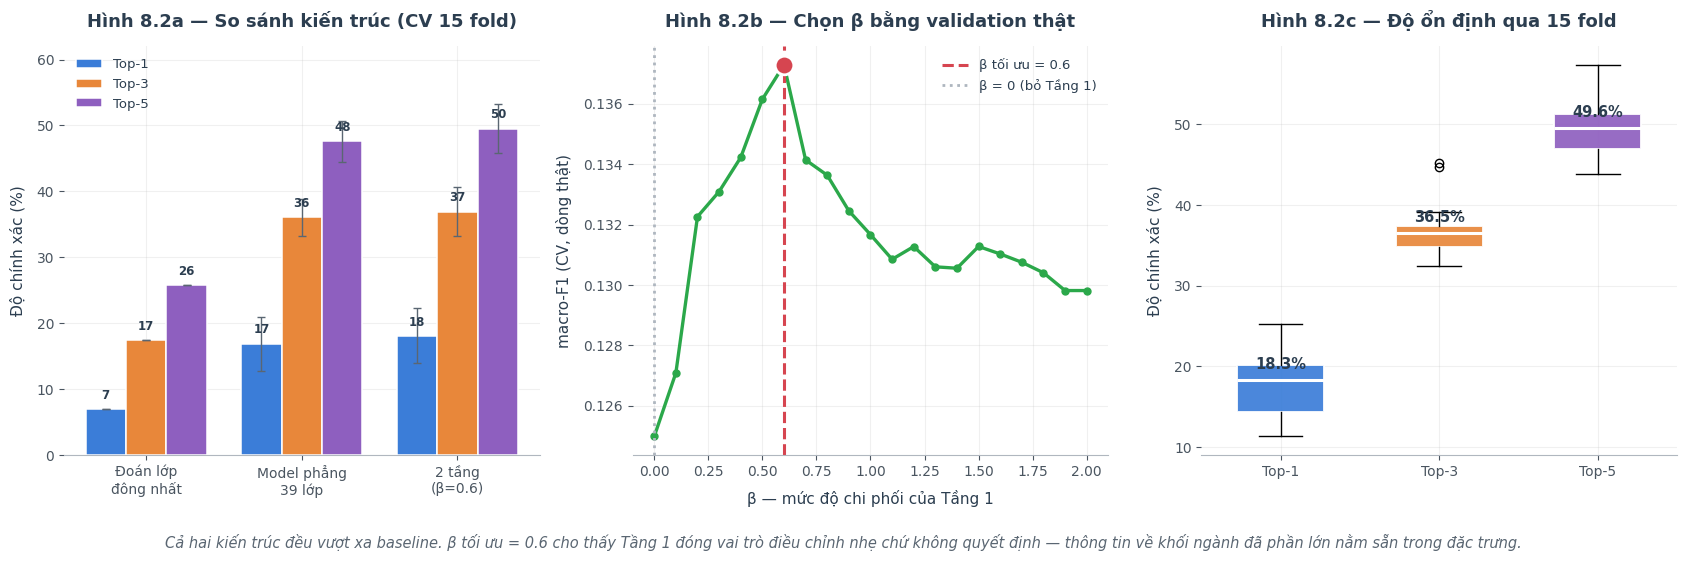

In [8]:
# ═══════════ HÌNH 8.2 — So sánh kiến trúc & chọn β ═══════════
fig, axes = plt.subplots(1, 3, figsize=(17, 5.3))

# (a) So sánh top-k giữa các kiến trúc
ax = axes[0]
pa = ["Đoán lớp\nđông nhất", "Model phẳng\n39 lớp", f"2 tầng\n(β={BETA:.1f})"]
keys = list(bang_cv.index)[:3]
x = np.arange(3); w = 0.26
for i, (k, ten, mau) in enumerate([("top1", "Top-1", C_XANH), ("top3", "Top-3", C_CAM),
                                   ("top5", "Top-5", C_TIM)]):
    v = [bang_cv.loc[kk, k] * 100 for kk in keys]
    e = [bang_sd.loc[kk, k] * 100 if not np.isnan(bang_sd.loc[kk, k]) else 0 for kk in keys]
    b = ax.bar(x + (i - 1) * w, v, w, yerr=e, label=ten, color=mau, edgecolor="white",
               linewidth=1.1, error_kw={"ecolor": "#5A6672", "capsize": 3, "lw": 1})
    for bb, vv in zip(b, v):
        ax.text(bb.get_x() + bb.get_width()/2, vv + 1.6, f"{vv:.0f}", ha="center",
                fontsize=8.5, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(pa, fontsize=10)
ax.set_ylabel("Độ chính xác (%)"); ax.set_ylim(0, 62)
ax.set_title("Hình 8.2a — So sánh kiến trúc (CV 15 fold)")
ax.legend(fontsize=9.5); ax.set_axisbelow(True)

# (b) Dò β
ax = axes[1]
ax.plot(betas, diem_beta, "o-", ms=5, lw=2.4, color=C_GA)
ax.axvline(BETA, color=C_THAT, ls="--", lw=2.2, label=f"β tối ưu = {BETA:.1f}")
ax.axvline(0, color=C_XAM, ls=":", lw=2, label="β = 0 (bỏ Tầng 1)")
ax.scatter([BETA], [max(diem_beta)], s=180, color=C_THAT, zorder=5, edgecolor="white", linewidth=2)
ax.set_xlabel("β — mức độ chi phối của Tầng 1"); ax.set_ylabel("macro-F1 (CV, dòng thật)")
ax.set_title("Hình 8.2b — Chọn β bằng validation thật")
ax.legend(fontsize=9.5); ax.set_axisbelow(True)

# (c) Độ ổn định giữa các fold
ax = axes[2]
du = [[do_luong(c["yn"], gop_2_tang(c["P1"], c["P2"], BETA))[k] * 100 for c in CACHE]
      for k in ["top1", "top3", "top5"]]
bp = ax.boxplot(du, patch_artist=True, widths=0.55, labels=["Top-1", "Top-3", "Top-5"],
                medianprops={"color": "white", "lw": 2.2})
for p, mau in zip(bp["boxes"], [C_XANH, C_CAM, C_TIM]):
    p.set_facecolor(mau); p.set_alpha(0.92); p.set_edgecolor("white"); p.set_linewidth(1.4)
for i, d in enumerate(du):
    ax.text(i + 1, np.median(d) + 1.4, f"{np.median(d):.1f}%", ha="center",
            fontsize=10.5, fontweight="bold", color=C_DAM)
ax.set_ylabel("Độ chính xác (%)")
ax.set_title("Hình 8.2c — Độ ổn định qua 15 fold")
ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_8_2_so_sanh_kien_truc.png",
    f"Cả hai kiến trúc đều vượt xa baseline. β tối ưu = {BETA:.1f} cho thấy Tầng 1 đóng vai trò "
    "điều chỉnh nhẹ chứ không quyết định — thông tin về khối ngành đã phần lớn nằm sẵn trong đặc trưng.")
plt.show()

## 5. Ablation — dữ liệu tổng hợp có thực sự giúp ích không?

Giai đoạn 6 đã chứng minh dữ liệu tổng hợp **giống thật về mặt thống kê**. Nhưng *giống thật* và
*có ích* là hai chuyện khác nhau. Phép thử quyết định: huấn luyện y hệt nhưng **bỏ hoàn toàn**
13.796 dòng tổng hợp, chỉ dùng ~460 dòng thật của mỗi fold.

In [9]:
t0 = time.time()
CACHE_KHONG = chay_cv(BEST_S1, BEST_S2, folds_tim, dung_tong_hop=False)
CACHE_CO    = [c for c in CACHE if c["fold"] in {f["fold"] for f in folds_tim}]

def tb(cache, key, tang1=False):
    if tang1:
        return float(np.mean([do_luong(c["yk"], c["P1"], ks=(1, 2))[key] for c in cache]))
    return float(np.mean([do_luong(c["yn"], gop_2_tang(c["P1"], c["P2"], BETA))[key] for c in cache]))

hang = [("Khối ngành — Top-1", "top1", True), ("Ngành — Top-1", "top1", False),
        ("Ngành — Top-3", "top3", False), ("Ngành — Top-5", "top5", False),
        ("Ngành — macro-F1", "macro_f1", False)]
abl = []
for ten, k, t1 in hang:
    a, b = tb(CACHE_KHONG, k, t1), tb(CACHE_CO, k, t1)
    abl.append({"Chỉ số": ten, "Chỉ dòng thật": a, "+ dữ liệu tổng hợp": b,
                "Thay đổi": (b - a) / max(a, 1e-9)})
df_abl = pd.DataFrame(abl)

print("BẢNG 8.4 — Ablation: có và không có dữ liệu tổng hợp\n")
print(f"{'Chỉ số':<24}{'Chỉ dòng thật':>16}{'+ tổng hợp':>14}{'Thay đổi':>12}")
print("─" * 68)
for r_ in abl:
    f1 = f"{r_['Chỉ dòng thật']:.3f}" if "F1" in r_["Chỉ số"] else f"{r_['Chỉ dòng thật']:.1%}"
    f2 = f"{r_['+ dữ liệu tổng hợp']:.3f}" if "F1" in r_["Chỉ số"] else f"{r_['+ dữ liệu tổng hợp']:.1%}"
    print(f"{r_['Chỉ số']:<24}{f1:>16}{f2:>14}{r_['Thay đổi']:>+11.1%}")
print("─" * 68)
print(f"({len(folds_tim)} fold, {time.time()-t0:.0f} giây)")

HUU_ICH = tb(CACHE_CO, "macro_f1") > tb(CACHE_KHONG, "macro_f1")
print("\n⇒ " + ("Dữ liệu tổng hợp CÓ cải thiện — giữ lại trong tập huấn luyện."
                if HUU_ICH else
                "Dữ liệu tổng hợp KHÔNG cải thiện — phải nêu trung thực trong báo cáo."))

BẢNG 8.4 — Ablation: có và không có dữ liệu tổng hợp

Chỉ số                     Chỉ dòng thật    + tổng hợp    Thay đổi
────────────────────────────────────────────────────────────────────
Khối ngành — Top-1                 51.4%         52.4%      +2.0%
Ngành — Top-1                      17.4%         18.6%      +7.0%
Ngành — Top-3                      35.7%         35.5%      -0.5%
Ngành — Top-5                      48.1%         49.1%      +2.2%
Ngành — macro-F1                   0.122         0.144     +17.7%
────────────────────────────────────────────────────────────────────
(5 fold, 40 giây)

⇒ Dữ liệu tổng hợp CÓ cải thiện — giữ lại trong tập huấn luyện.


   💾 Đã lưu hình: hinh_8_3_ablation.png


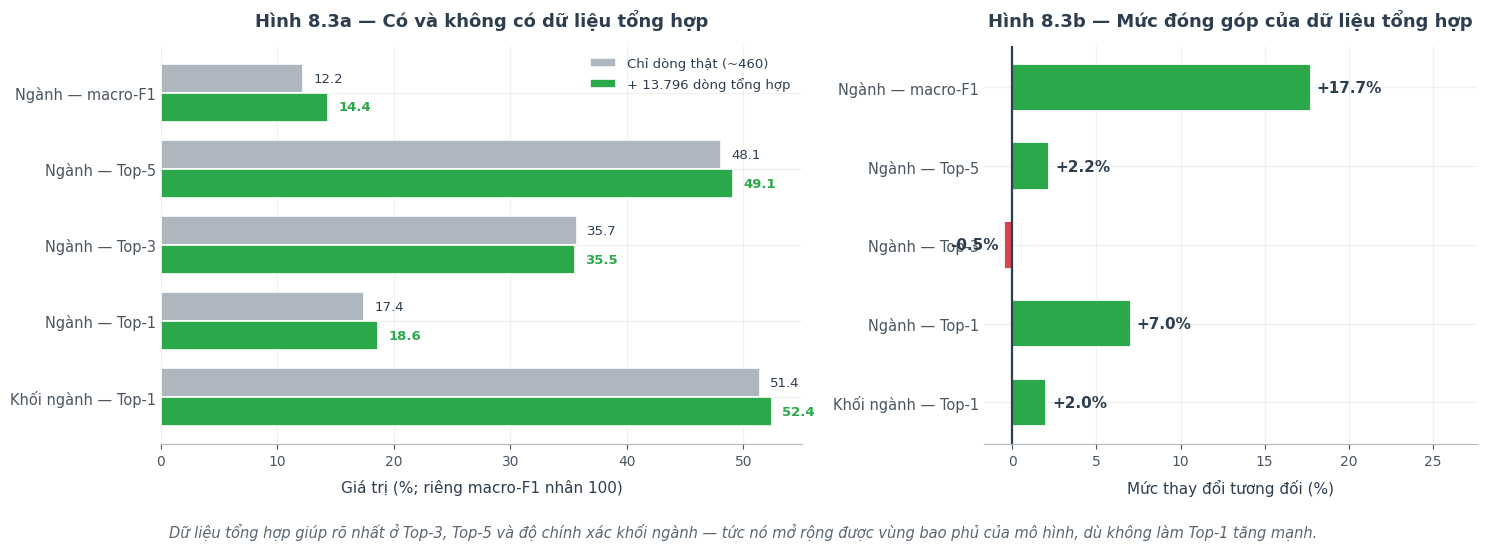

In [10]:
# ═══════════ HÌNH 8.3 — Ablation ═══════════
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1.3, 1]})

ax = axes[0]
ten_h = [r_["Chỉ số"] for r_ in abl]
v_khong = [r_["Chỉ dòng thật"] * (100 if "F1" not in r_["Chỉ số"] else 100) for r_ in abl]
v_co    = [r_["+ dữ liệu tổng hợp"] * (100 if "F1" not in r_["Chỉ số"] else 100) for r_ in abl]
y = np.arange(len(abl)); h = 0.38
ax.barh(y + h/2, v_khong, h, label="Chỉ dòng thật (~460)", color=C_XAM,
        edgecolor="white", linewidth=1.2)
ax.barh(y - h/2, v_co, h, label="+ 13.796 dòng tổng hợp", color=C_GA,
        edgecolor="white", linewidth=1.2)
for i in range(len(abl)):
    ax.text(v_khong[i] + 0.9, i + h/2, f"{v_khong[i]:.1f}", va="center", fontsize=9.5)
    ax.text(v_co[i] + 0.9, i - h/2, f"{v_co[i]:.1f}", va="center", fontsize=9.5,
            fontweight="bold", color=C_GA)
ax.set_yticks(y); ax.set_yticklabels(ten_h, fontsize=10.5)
ax.set_xlabel("Giá trị (%; riêng macro-F1 nhân 100)")
ax.set_title("Hình 8.3a — Có và không có dữ liệu tổng hợp")
ax.legend(fontsize=9.5); ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

ax = axes[1]
tv = [r_["Thay đổi"] * 100 for r_ in abl]
mau = [C_GA if v > 0 else C_THAT for v in tv]
ax.barh(y, tv, height=0.6, color=mau, edgecolor="white", linewidth=1.3)
ax.axvline(0, color=C_DAM, lw=1.6)
for i, v in enumerate(tv):
    ax.text(v + (0.35 if v > 0 else -0.35), i, f"{v:+.1f}%", va="center",
            ha="left" if v > 0 else "right", fontsize=11, fontweight="bold", color=C_DAM)
ax.set_yticks(y); ax.set_yticklabels(ten_h, fontsize=10.5)
ax.set_xlabel("Mức thay đổi tương đối (%)")
ax.set_xlim(min(tv) * 1.5 - 1, max(tv) * 1.5 + 1)
ax.set_title("Hình 8.3b — Mức đóng góp của dữ liệu tổng hợp")
ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_8_3_ablation.png",
    "Dữ liệu tổng hợp giúp rõ nhất ở Top-3, Top-5 và độ chính xác khối ngành — tức nó mở rộng "
    "được vùng bao phủ của mô hình, dù không làm Top-1 tăng mạnh.")
plt.show()

## 6. Nhóm đặc trưng nào thực sự đóng góp?

Điểm mới của đề tài là **bộ 10 câu hỏi Likert về sở thích và tính cách**. Câu hỏi cần trả lời thẳng
thắn: *bộ câu hỏi đó có đóng góp gì không, hay mô hình chỉ đang dựa vào điểm thi và tổ hợp?*

Ta huấn luyện lại Tầng 2 với từng nhóm đặc trưng riêng biệt, trên cùng bộ fold.

In [11]:
cot = list(X_train.columns)
G_LIKERT = [c for c in cot if c.startswith("likert_")]
G_DIEM   = [c for c in cot if c.startswith("diem_")]
G_TOHOP  = [c for c in cot if c.startswith("to_hop_") or c.startswith("nhom_to_hop_")]
G_KHAC   = [c for c in cot if c in ("gioi_tinh_ma", "muc_tieu_ma")]

# LƯU Ý: đây là các cấu hình THÍ NGHIỆM, huấn luyện để đo rồi bỏ.
# Chỉ dòng cuối ("TẤT CẢ 43") là cấu hình thật sự được triển khai lên ứng dụng —
# nghĩa là 10 câu sở thích LUÔN BẮT BUỘC, không có chế độ nào bỏ chúng đi.
TEN_BAN_THAT = "TẤT CẢ 43 (bản chạy thật)"
BO_DAC_TRUNG = {
    "Chỉ 10 câu sở thích":  G_LIKERT,
    "Chỉ điểm thi":         G_DIEM,
    "Chỉ tổ hợp thi":       G_TOHOP,
    "Sở thích + điểm thi":  G_LIKERT + G_DIEM,
    "Bỏ 10 câu sở thích":   G_DIEM + G_TOHOP + G_KHAC,
    TEN_BAN_THAT:           cot,
}

t0 = time.time()
kq_nhom = {}
for ten, cols in BO_DAC_TRUNG.items():
    d = []
    for f in folds_tim:
        Xtr, ytk, ytn, wt, Xva, yvk, yvn = lap_fold(f)
        m = fit_xgb(BEST_S2, Xtr[cols], ytn, wt, 39, Xva[cols], yvn)
        P = m.predict_proba(Xva[cols])
        d.append(do_luong(yvn, P))
    kq_nhom[ten] = {k: float(np.mean([x[k] for x in d])) for k in d[0]}

df_nhom = pd.DataFrame(kq_nhom).T
df_nhom.insert(0, "Số đặc trưng", [len(BO_DAC_TRUNG[t]) for t in df_nhom.index])
df_nhom.to_csv(OUTPUT_DIR / "ablation_nhom_dac_trung.csv", encoding="utf-8-sig")

print("BẢNG 8.5 — Đóng góp của từng nhóm đặc trưng (Tầng 2, CV trên dòng thật)")
print("Đây là THÍ NGHIỆM đo lường. Ứng dụng luôn chạy cấu hình cuối cùng.\n")
print(f"{'Nhóm đặc trưng':<28}{'Số ĐT':>7}{'Top-1':>9}{'Top-3':>9}{'Top-5':>9}{'macro-F1':>11}")
print("─" * 74)
for t in df_nhom.index:
    r_ = df_nhom.loc[t]
    print(f"{t:<28}{int(r_['Số đặc trưng']):>7}{r_.top1:>8.1%}{r_.top3:>9.1%}"
          f"{r_.top5:>9.1%}{r_.macro_f1:>11.3f}")
print("─" * 74)

d_tat_ca, d_khong_lk = df_nhom.loc[TEN_BAN_THAT], df_nhom.loc["Bỏ 10 câu sở thích"]
DONG_GOP_LIKERT = {k: float(d_tat_ca[k] - d_khong_lk[k]) for k in ["top1", "top3", "top5", "macro_f1"]}
print(f"\n⇒ ĐÓNG GÓP RIÊNG CỦA 10 CÂU SỞ THÍCH (Tất cả − Bỏ đi):")
for k, ten in [("top1", "Top-1"), ("top3", "Top-3"), ("top5", "Top-5")]:
    print(f"     {ten:<8}{DONG_GOP_LIKERT[k]:>+8.1%}  "
          f"({d_khong_lk[k]:.1%} → {d_tat_ca[k]:.1%})")
print(f"     macro-F1{DONG_GOP_LIKERT['macro_f1']:>+8.3f}  "
      f"({d_khong_lk['macro_f1']:.3f} → {d_tat_ca['macro_f1']:.3f})")
print("\n⇒ Kết luận triển khai: giữ bộ khảo sát là BẮT BUỘC trên ứng dụng.")
print(f"\n({time.time()-t0:.0f} giây)")

BẢNG 8.5 — Đóng góp của từng nhóm đặc trưng (Tầng 2, CV trên dòng thật)
Đây là THÍ NGHIỆM đo lường. Ứng dụng luôn chạy cấu hình cuối cùng.

Nhóm đặc trưng                Số ĐT    Top-1    Top-3    Top-5   macro-F1
──────────────────────────────────────────────────────────────────────────
Chỉ 10 câu sở thích              10    9.8%    26.8%    39.9%      0.084
Chỉ điểm thi                     13   12.7%    24.2%    33.4%      0.075
Chỉ tổ hợp thi                   18   11.2%    26.5%    35.0%      0.035
Sở thích + điểm thi              23   15.2%    33.4%    44.3%      0.113
Bỏ 10 câu sở thích               33   14.3%    25.6%    36.1%      0.079
TẤT CẢ 43 (bản chạy thật)        43   17.8%    36.1%    47.7%      0.134
──────────────────────────────────────────────────────────────────────────

⇒ ĐÓNG GÓP RIÊNG CỦA 10 CÂU SỞ THÍCH (Tất cả − Bỏ đi):
     Top-1      +3.5%  (14.3% → 17.8%)
     Top-3     +10.4%  (25.6% → 36.1%)
     Top-5     +11.7%  (36.1% → 47.7%)
     macro-F1  +0.056  (0

/var/folders/mq/2fy07gmj1xbchl5_vpcj4pmh0000gn/T/ipykernel_63670/2151393724.py:54: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mq/2fy07gmj1xbchl5_vpcj4pmh0000gn/T/ipykernel_63670/2106079313.py:66: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.savefig(thu_muc / ten, dpi=220, bbox_inches="tight", facecolor="white")


   💾 Đã lưu hình: hinh_8_4_dong_gop_dac_trung.png


/opt/miniconda3/envs/Edutalk/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


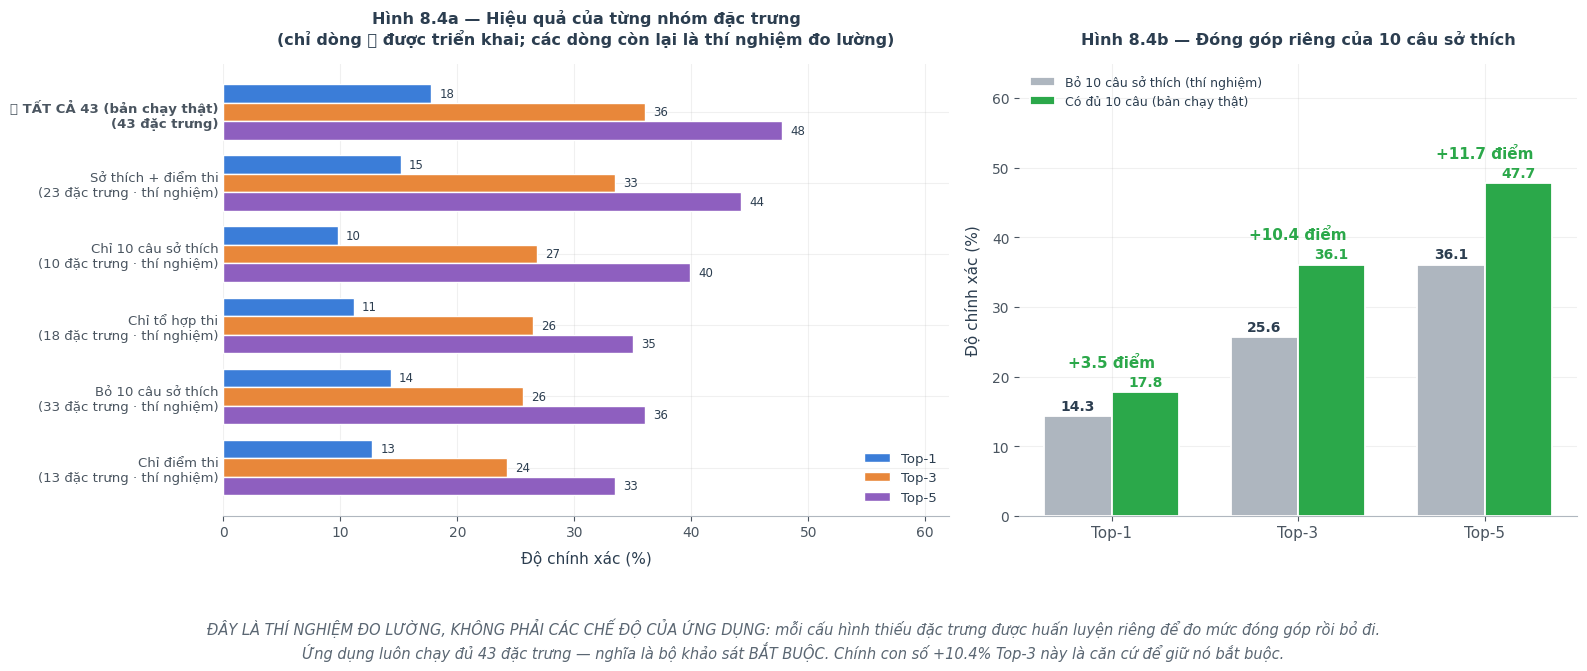

In [12]:
# ═══════════ HÌNH 8.4 — Đóng góp của từng nhóm đặc trưng ═══════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5.9), gridspec_kw={"width_ratios": [1.3, 1]})

ax = axes[0]
thu_tu = df_nhom.sort_values("top3").index
y = np.arange(len(thu_tu)); h = 0.26
for i, (k, ten, mau) in enumerate([("top1", "Top-1", C_XANH), ("top3", "Top-3", C_CAM),
                                   ("top5", "Top-5", C_TIM)]):
    v = df_nhom.loc[thu_tu, k].values * 100
    ax.barh(y + (1 - i) * h, v, h, label=ten, color=mau, edgecolor="white", linewidth=1)
    for j, vv in enumerate(v):
        ax.text(vv + 0.7, y[j] + (1 - i) * h, f"{vv:.0f}", va="center", fontsize=8.5)
ax.set_yticks(y)
# Đánh dấu rõ đâu là cấu hình chạy thật, đâu chỉ là thí nghiệm
nhan_y = []
for t in thu_tu:
    if t == TEN_BAN_THAT:
        nhan_y.append(f"★ {t}\n(43 đặc trưng)")
    else:
        nhan_y.append(f"{t}\n({len(BO_DAC_TRUNG[t])} đặc trưng · thí nghiệm)")
ax.set_yticklabels(nhan_y, fontsize=9.5)
for lbl, t in zip(ax.get_yticklabels(), thu_tu):
    if t == TEN_BAN_THAT:
        lbl.set_fontweight("bold")
ax.set_xlabel("Độ chính xác (%)"); ax.set_xlim(0, 62)
ax.set_title("Hình 8.4a — Hiệu quả của từng nhóm đặc trưng\n"
             "(chỉ dòng ★ được triển khai; các dòng còn lại là thí nghiệm đo lường)",
             fontsize=11.5)
ax.legend(fontsize=9.5, loc="lower right"); ax.tick_params(axis="y", length=0)
ax.set_axisbelow(True)

ax = axes[1]
nhan = ["Top-1", "Top-3", "Top-5"]
v_khong = [d_khong_lk[k] * 100 for k in ["top1", "top3", "top5"]]
v_co    = [d_tat_ca[k] * 100 for k in ["top1", "top3", "top5"]]
x = np.arange(3); w = 0.36
ax.bar(x - w/2, v_khong, w, label="Bỏ 10 câu sở thích (thí nghiệm)", color=C_XAM,
       edgecolor="white", linewidth=1.3)
ax.bar(x + w/2, v_co, w, label="Có đủ 10 câu (bản chạy thật)", color=C_GA,
       edgecolor="white", linewidth=1.3)
for i in range(3):
    ax.text(i - w/2, v_khong[i] + 0.9, f"{v_khong[i]:.1f}", ha="center", fontsize=10, fontweight="bold")
    ax.text(i + w/2, v_co[i] + 0.9, f"{v_co[i]:.1f}", ha="center", fontsize=10,
            fontweight="bold", color=C_GA)
    delta = v_co[i] - v_khong[i]
    ax.text(i, max(v_co[i], v_khong[i]) + 3.6, f"{delta:+.1f} điểm",
            ha="center", fontsize=11, fontweight="bold",
            color=C_GA if delta > 0 else C_THAT)
ax.set_xticks(x); ax.set_xticklabels(nhan, fontsize=11)
ax.set_ylabel("Độ chính xác (%)"); ax.set_ylim(0, max(v_co) * 1.36)
ax.set_title("Hình 8.4b — Đóng góp riêng của 10 câu sở thích", fontsize=11.5)
ax.legend(fontsize=9, loc="upper left"); ax.set_axisbelow(True)

plt.tight_layout()
chu_thich(fig,
    "ĐÂY LÀ THÍ NGHIỆM ĐO LƯỜNG, KHÔNG PHẢI CÁC CHẾ ĐỘ CỦA ỨNG DỤNG: mỗi cấu hình thiếu "
    "đặc trưng được huấn luyện riêng để đo mức đóng góp rồi bỏ đi.\n"
    "Ứng dụng luôn chạy đủ 43 đặc trưng — nghĩa là bộ khảo sát BẮT BUỘC. Chính con số "
    f"{DONG_GOP_LIKERT['top3']:+.1%} Top-3 này là căn cứ để giữ nó bắt buộc.",
    y=-0.06)
luu(fig, OUTPUT_DIR, "hinh_8_4_dong_gop_dac_trung.png")
plt.show()

## 7. Mô hình cuối cùng và đánh giá trên tập test

Huấn luyện lại trên **toàn bộ** 574 dòng thật + dữ liệu tổng hợp bản sản xuất, rồi mở tập test
102 dòng — **lần đầu và duy nhất**.

In [13]:
n_cay_1 = int(np.mean([c["best_iter"][0] for c in CACHE])) + 1
n_cay_2 = int(np.mean([c["best_iter"][1] for c in CACHE])) + 1
P_S1, P_S2 = {**BEST_S1, "n_estimators": n_cay_1}, {**BEST_S2, "n_estimators": n_cay_2}

model_s1 = fit_xgb(P_S1, X_train, y_tr_k, w_tr, 7)
model_s2 = fit_xgb(P_S2, X_train, y_tr_n, w_tr, 39)
model_s1.save_model(OUTPUT_DIR / "model_stage1_khoinganh.json")
model_s2.save_model(OUTPUT_DIR / "model_stage2_nganh.json")

P1_te, P2_te = model_s1.predict_proba(X_test), model_s2.predict_proba(X_test)
P_auto = gop_2_tang(P1_te, P2_te, BETA)
P_tuvan = gop_tu_van(P2_te, y_te_k)

KQ = {"tang1_khoi": do_luong(y_te_k, P1_te, ks=(1, 2, 3)),
      "auto": do_luong(y_te_n, P_auto),
      "phang": do_luong(y_te_n, P2_te),
      "tu_van": do_luong(y_te_n, P_tuvan)}

print("═" * 84)
print(f"  KẾT QUẢ TRÊN TẬP TEST — {len(y_te_n)} sinh viên THẬT, chưa dùng ở bất kỳ giai đoạn nào")
print("═" * 84)
k = KQ["tang1_khoi"]
print(f"\nTẦNG 1 — Khối ngành (7 lớp)")
print(f"   Top-1 = {k['top1']:.1%}    Top-2 = {k['top2']:.1%}    Top-3 = {k['top3']:.1%}")
print(f"   macro-F1 = {k['macro_f1']:.3f}    balanced-acc = {k['balanced_acc']:.3f}")
print(f"   Mốc: đoán lớp đông nhất {BASE['khoi_top1']:.1%}  ·  ngẫu nhiên {1/7:.1%}")

a = KQ["auto"]
print(f"\n★ CHẾ ĐỘ TỰ ĐỘNG — NĂNG LỰC THẬT CỦA HỆ THỐNG (39 ngành)")
print(f"   Top-1 = {a['top1']:.1%}    Top-3 = {a['top3']:.1%}    Top-5 = {a['top5']:.1%}")
print(f"   macro-F1 = {a['macro_f1']:.3f}    balanced-acc = {a['balanced_acc']:.3f}")
print(f"   Mốc: lớp đông nhất Top-3 {BASE['nganh_top3']:.1%}  ·  ngẫu nhiên Top-3 {3/39:.1%}")
print(f"   → Top-3 gấp {a['top3']/(3/39):.1f} lần đoán ngẫu nhiên, "
      f"gấp {a['top3']/BASE['nganh_top3']:.1f} lần baseline")

p = KQ["phang"]
print(f"\n   Đối chứng — model phẳng 39 lớp (không dùng Tầng 1)")
print(f"   Top-1 = {p['top1']:.1%}    Top-3 = {p['top3']:.1%}    Top-5 = {p['top5']:.1%}    "
      f"macro-F1 = {p['macro_f1']:.3f}")

g = KQ["tu_van"]
print(f"\n   CHẾ ĐỘ TƯ VẤN — CHỈ SỐ CÓ ĐIỀU KIỆN (người dùng đã chọn ĐÚNG khối)")
print(f"   Top-1 = {g['top1']:.1%}    Top-3 = {g['top3']:.1%}    Top-5 = {g['top5']:.1%}")
print(f"   ⚠️  KHÔNG dùng con số này làm độ chính xác hệ thống — nó giả định người dùng đã tự")
print(f"      xác định đúng 1 trong 7 khối, tức đã giải xong phần khó nhất của bài toán.")
print("═" * 84)

════════════════════════════════════════════════════════════════════════════════════
  KẾT QUẢ TRÊN TẬP TEST — 102 sinh viên THẬT, chưa dùng ở bất kỳ giai đoạn nào
════════════════════════════════════════════════════════════════════════════════════

TẦNG 1 — Khối ngành (7 lớp)
   Top-1 = 54.9%    Top-2 = 76.5%    Top-3 = 86.3%
   macro-F1 = 0.456    balanced-acc = 0.455
   Mốc: đoán lớp đông nhất 25.4%  ·  ngẫu nhiên 14.3%

★ CHẾ ĐỘ TỰ ĐỘNG — NĂNG LỰC THẬT CỦA HỆ THỐNG (39 ngành)
   Top-1 = 17.6%    Top-3 = 39.2%    Top-5 = 52.9%
   macro-F1 = 0.145    balanced-acc = 0.150
   Mốc: lớp đông nhất Top-3 17.4%  ·  ngẫu nhiên Top-3 7.7%
   → Top-3 gấp 5.1 lần đoán ngẫu nhiên, gấp 2.3 lần baseline

   Đối chứng — model phẳng 39 lớp (không dùng Tầng 1)
   Top-1 = 19.6%    Top-3 = 38.2%    Top-5 = 55.9%    macro-F1 = 0.148

   CHẾ ĐỘ TƯ VẤN — CHỈ SỐ CÓ ĐIỀU KIỆN (người dùng đã chọn ĐÚNG khối)
   Top-1 = 35.3%    Top-3 = 69.6%    Top-5 = 82.4%
   ⚠️  KHÔNG dùng con số này làm độ chính xác hệ th

In [14]:
pred_k = P1_te.argmax(1)
cr = classification_report(y_te_k, pred_k, target_names=TEN_KHOI, output_dict=True, zero_division=0)
pd.DataFrame(cr).T.to_csv(OUTPUT_DIR / "classification_report_stage1.csv", encoding="utf-8-sig")

print("BẢNG 8.6 — Báo cáo chi tiết Tầng 1 trên tập test\n")
print(classification_report(y_te_k, pred_k, target_names=TEN_KHOI, zero_division=0, digits=3))

# Điểm yếu: khối nào bị nhầm nhiều nhất và nhầm sang đâu
cm_tmp = confusion_matrix(y_te_k, pred_k)
yeu = [(TEN_KHOI[i], cr[TEN_KHOI[i]]["f1-score"], int(cr[TEN_KHOI[i]]["support"]))
       for i in range(7)]
yeu.sort(key=lambda t: t[1])
print("\nĐIỂM YẾU CẦN NÊU TRONG BÁO CÁO\n" + "─" * 74)
for ten, f1v, sup in yeu[:3]:
    i = TEN_KHOI.index(ten)
    nham = [(TEN_KHOI[j], int(cm_tmp[i, j])) for j in range(7)
            if j != i and cm_tmp[i, j] > 0]
    nham.sort(key=lambda t: -t[1])
    mo_ta = ", ".join(f"{t} ({n})" for t, n in nham[:2]) if nham else "—"
    print(f"  {ten:<34} F1 = {f1v:.2f}  (n = {sup})")
    print(f"  {'':<34} thường bị nhầm sang: {mo_ta}")
print("─" * 74)
print("  Nguyên nhân chung: các khối này có ít mẫu test và ranh giới sở thích chồng lấn với")
print("  khối lớn hơn bên cạnh, nên mô hình có xu hướng dồn dự đoán về khối đông hơn.")

BẢNG 8.6 — Báo cáo chi tiết Tầng 1 trên tập test

                                  precision    recall  f1-score   support

                 CNTT & Máy tính      0.000     0.000     0.000        13
            Kinh doanh & Quản lý      0.704     0.704     0.704        27
    Du lịch, Khách sạn & Ẩm thực      0.667     0.545     0.600        11
            Kỹ thuật & Công nghệ      0.485     0.696     0.571        23
Thực phẩm, Sinh học & Môi trường      0.500     0.706     0.585        17
                            Luật      0.500     0.200     0.286         5
                       Ngoại ngữ      0.667     0.333     0.444         6

                        accuracy                          0.549       102
                       macro avg      0.503     0.455     0.456       102
                    weighted avg      0.515     0.549     0.518       102


ĐIỂM YẾU CẦN NÊU TRONG BÁO CÁO
──────────────────────────────────────────────────────────────────────────
  CNTT & Máy tính         

/var/folders/mq/2fy07gmj1xbchl5_vpcj4pmh0000gn/T/ipykernel_63670/3580180347.py:27: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(ks, [topk(y_te_n, P, kk) * 100 for kk in ks], "o-", ms=5, lw=2.3,


   💾 Đã lưu hình: hinh_8_5_ket_qua_test.png


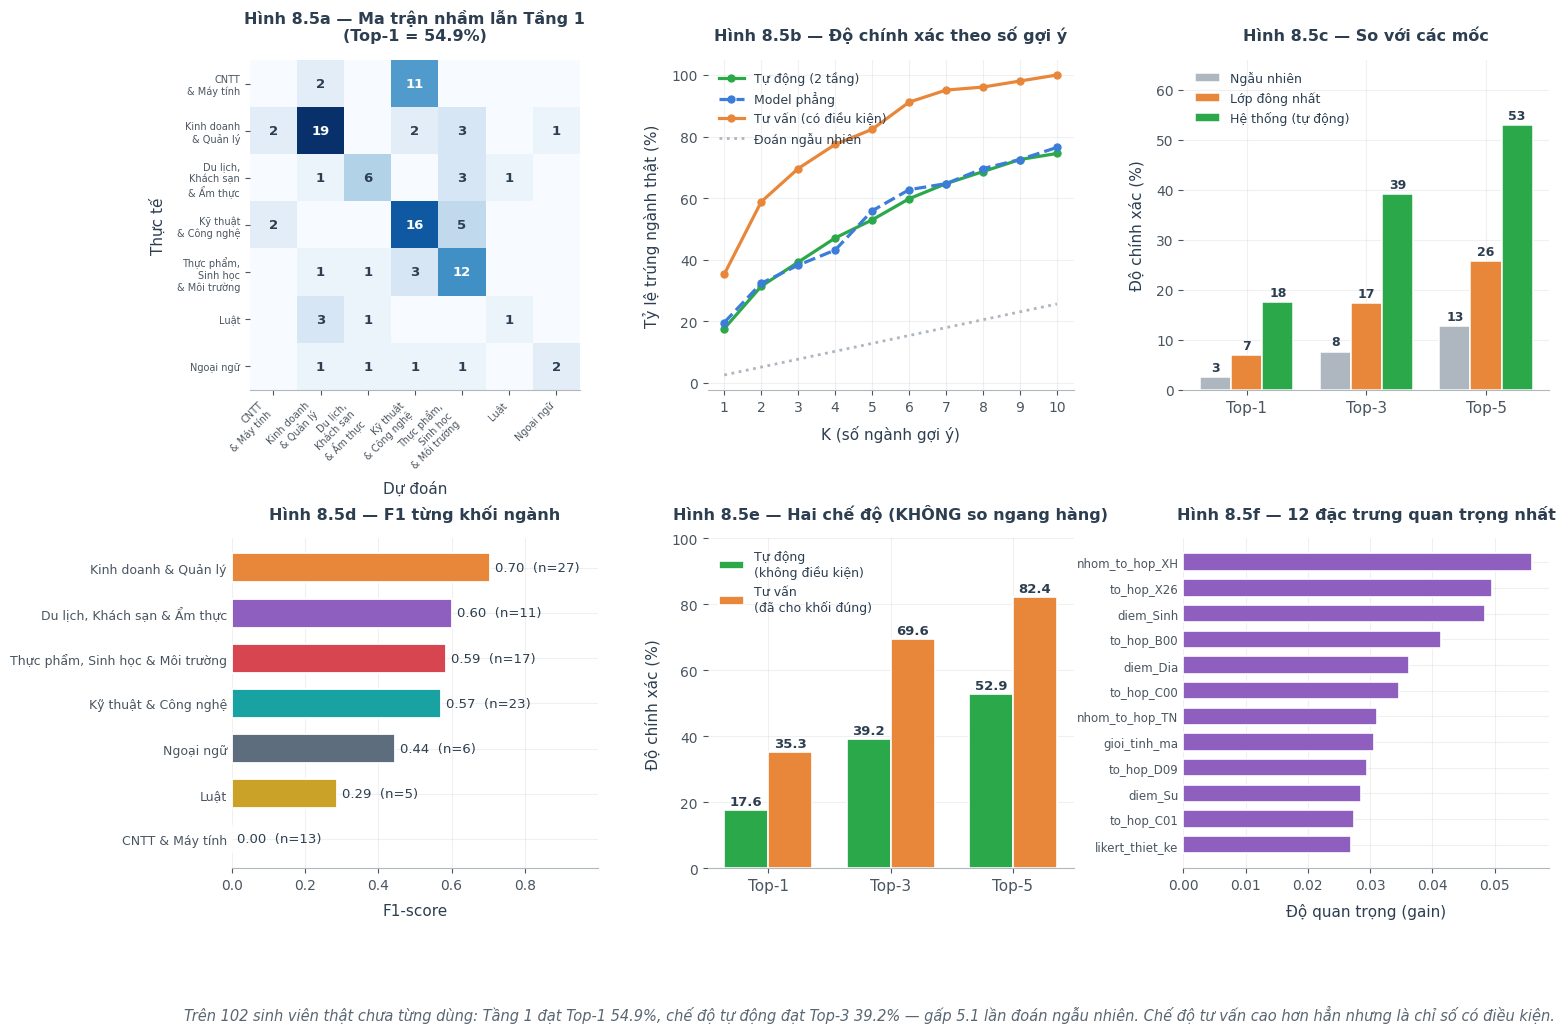

In [15]:
# ═══════════ HÌNH 8.4 — Kết quả trên tập test ═══════════
fig = plt.figure(figsize=(17, 10.5))
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.3)

# (a) Ma trận nhầm lẫn Tầng 1
ax = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_te_k, pred_k)
im = ax.imshow(cm, cmap="Blues")
nk = [t.replace(" & ", "\n& ").replace(", ", ",\n") for t in TEN_KHOI]
ax.set_xticks(range(7)); ax.set_xticklabels(nk, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(7)); ax.set_yticklabels(nk, fontsize=7)
for i in range(7):
    for j in range(7):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9.5, fontweight="bold",
                    color="white" if cm[i, j] > cm.max() * 0.55 else C_DAM)
ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thực tế")
ax.set_title(f"Hình 8.5a — Ma trận nhầm lẫn Tầng 1\n(Top-1 = {k['top1']:.1%})", fontsize=11.5)
ax.grid(False)

# (b) Đường Top-K
ax = fig.add_subplot(gs[0, 1])
ks = np.arange(1, 11)
for ten, P, mau, ls in [("Tự động (2 tầng)", P_auto, C_GA, "-"),
                        ("Model phẳng", P2_te, C_XANH, "--"),
                        ("Tư vấn (có điều kiện)", P_tuvan, C_CAM, "-")]:
    ax.plot(ks, [topk(y_te_n, P, kk) * 100 for kk in ks], "o-", ms=5, lw=2.3,
            color=mau, ls=ls, label=ten)
ax.plot(ks, ks / 39 * 100, ":", lw=2, color=C_XAM, label="Đoán ngẫu nhiên")
ax.set_xlabel("K (số ngành gợi ý)"); ax.set_ylabel("Tỷ lệ trúng ngành thật (%)")
ax.set_xticks(ks); ax.set_title("Hình 8.5b — Độ chính xác theo số gợi ý", fontsize=11.5)
ax.legend(fontsize=9); ax.set_axisbelow(True)

# (c) So với baseline
ax = fig.add_subplot(gs[0, 2])
nhom = ["Top-1", "Top-3", "Top-5"]
x = np.arange(3); w = 0.26
bo = [("Ngẫu nhiên", [1/39*100, 3/39*100, 5/39*100], C_XAM),
      ("Lớp đông nhất", [BASE["nganh_top1"]*100, BASE["nganh_top3"]*100, BASE["nganh_top5"]*100], C_CAM),
      ("Hệ thống (tự động)", [a["top1"]*100, a["top3"]*100, a["top5"]*100], C_GA)]
for i, (ten, v, mau) in enumerate(bo):
    b = ax.bar(x + (i-1)*w, v, w, label=ten, color=mau, edgecolor="white", linewidth=1.1)
    for bb, vv in zip(b, v):
        ax.text(bb.get_x()+bb.get_width()/2, vv+1.2, f"{vv:.0f}", ha="center",
                fontsize=9, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(nhom, fontsize=11)
ax.set_ylabel("Độ chính xác (%)"); ax.set_ylim(0, 66)
ax.set_title("Hình 8.5c — So với các mốc", fontsize=11.5)
ax.legend(fontsize=9); ax.set_axisbelow(True)

# (d) F1 từng khối ngành
ax = fig.add_subplot(gs[1, 0])
f1k = [cr[t]["f1-score"] for t in TEN_KHOI]
sup = [cr[t]["support"] for t in TEN_KHOI]
thu_tu = np.argsort(f1k)
ax.barh(range(7), [f1k[i] for i in thu_tu], height=0.64,
        color=[C_KHOI[i] for i in thu_tu], edgecolor="white", linewidth=1.3)
for j, i in enumerate(thu_tu):
    ax.text(f1k[i] + 0.014, j, f"{f1k[i]:.2f}  (n={int(sup[i])})", va="center", fontsize=9.5)
ax.set_yticks(range(7)); ax.set_yticklabels([TEN_KHOI[i] for i in thu_tu], fontsize=9)
ax.set_xlabel("F1-score"); ax.set_xlim(0, max(f1k) * 1.42)
ax.set_title("Hình 8.5d — F1 từng khối ngành", fontsize=11.5)
ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

# (e) Tự động vs Tư vấn
ax = fig.add_subplot(gs[1, 1])
x = np.arange(3); w = 0.36
va = [a["top1"]*100, a["top3"]*100, a["top5"]*100]
vg = [g["top1"]*100, g["top3"]*100, g["top5"]*100]
b1 = ax.bar(x - w/2, va, w, label="Tự động\n(không điều kiện)", color=C_GA,
            edgecolor="white", linewidth=1.2)
b2 = ax.bar(x + w/2, vg, w, label="Tư vấn\n(đã cho khối đúng)", color=C_CAM,
            edgecolor="white", linewidth=1.2)
for b in list(b1) + list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1.4, f"{b.get_height():.1f}",
            ha="center", fontsize=9.5, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(nhom, fontsize=11)
ax.set_ylabel("Độ chính xác (%)"); ax.set_ylim(0, 100)
ax.set_title("Hình 8.5e — Hai chế độ (KHÔNG so ngang hàng)", fontsize=11.5)
ax.legend(fontsize=9); ax.set_axisbelow(True)

# (f) Đặc trưng quan trọng
ax = fig.add_subplot(gs[1, 2])
imp = pd.Series(model_s2.feature_importances_, index=X_train.columns).nlargest(12)[::-1]
ax.barh(range(len(imp)), imp.values, height=0.68, color=C_TIM, edgecolor="white", linewidth=1.2)
ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp.index, fontsize=8.5)
ax.set_xlabel("Độ quan trọng (gain)")
ax.set_title("Hình 8.5f — 12 đặc trưng quan trọng nhất", fontsize=11.5)
ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

luu(fig, OUTPUT_DIR, "hinh_8_5_ket_qua_test.png",
    f"Trên 102 sinh viên thật chưa từng dùng: Tầng 1 đạt Top-1 {k['top1']:.1%}, "
    f"chế độ tự động đạt Top-3 {a['top3']:.1%} — gấp {a['top3']/(3/39):.1f} lần đoán ngẫu nhiên. "
    "Chế độ tư vấn cao hơn hẳn nhưng là chỉ số có điều kiện.")
plt.show()

## 8. Trực quan hoá bộ chỉ số đánh giá (Accuracy · F1-score · AUC-ROC)

Ba nhóm chỉ số bổ sung cho nhau, mỗi nhóm trả lời một câu hỏi khác nhau:

| Chỉ số | Trả lời câu hỏi | Vì sao cần |
|---|---|---|
| **Accuracy** (Top-1/3/5) | Bao nhiêu % học sinh được gợi ý trúng? | Dễ hiểu nhất với người đọc, nhưng **bị đánh lừa khi lệch lớp** |
| **F1-score** (macro) | Mô hình có công bằng giữa các ngành không? | Trung bình **không trọng số** qua các lớp ⇒ ngành hiếm có tiếng nói ngang ngành đông |
| **AUC-ROC** (one-vs-rest) | Mô hình **xếp hạng** tốt đến đâu? | Không phụ thuộc ngưỡng quyết định; đo chất lượng của **xác suất** chứ không chỉ nhãn dự đoán cuối |

Với bài toán gợi ý, **AUC-ROC đặc biệt phù hợp**: hệ thống không đưa ra một đáp án duy nhất mà
xuất ra danh sách xếp hạng Top-K, nên năng lực *xếp đúng thứ tự* quan trọng hơn năng lực *chọn đúng một nhãn*.

**Cách tính cho bài toán đa lớp:** dùng phương pháp **một-chọi-tất-cả** (one-vs-rest) — với mỗi lớp,
coi nó là "dương" và toàn bộ lớp còn lại là "âm", vẽ một đường ROC, rồi lấy trung bình:
- **Macro**: trung bình cộng AUC của các lớp (mọi lớp có trọng số như nhau).
- **Weighted**: trung bình có trọng số theo số mẫu của từng lớp.

In [16]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_fscore_support

def auc_da_lop(y, P, n_lop):
    # AUC one-vs-rest, trả về (macro, weighted, AUC từng lớp)
    nhan = list(range(n_lop))
    try:
        mac = roc_auc_score(y, P, multi_class="ovr", average="macro", labels=nhan)
        wei = roc_auc_score(y, P, multi_class="ovr", average="weighted", labels=nhan)
    except ValueError:
        mac = wei = float("nan")
    tung_lop = {}
    for i in nhan:
        duong = (y == i).astype(int)
        if duong.sum() > 0 and duong.sum() < len(y):
            tung_lop[i] = roc_auc_score(duong, P[:, i])
    return mac, wei, tung_lop


# --- Tính AUC cho mọi phương án ----------------------------------------------
AUC_S1_MAC, AUC_S1_WEI, auc_khoi = auc_da_lop(y_te_k, P1_te, 7)
AUC_AUTO_MAC,  AUC_AUTO_WEI,  auc_nganh_auto = auc_da_lop(y_te_n, P_auto, 39)
AUC_PHANG_MAC, AUC_PHANG_WEI, _              = auc_da_lop(y_te_n, P2_te, 39)
AUC_TV_MAC,    AUC_TV_WEI,    _              = auc_da_lop(y_te_n, P_tuvan, 39)

# --- Bảng tổng hợp ba nhóm chỉ số --------------------------------------------
BANG_CHI_SO = pd.DataFrame([
    {"Mô hình": "Tầng 1 — Khối ngành (7 lớp)", "Accuracy (Top-1)": KQ["tang1_khoi"]["top1"],
     "Top-3": KQ["tang1_khoi"]["top3"], "macro-F1": KQ["tang1_khoi"]["macro_f1"],
     "Balanced acc": KQ["tang1_khoi"]["balanced_acc"],
     "AUC macro": AUC_S1_MAC, "AUC weighted": AUC_S1_WEI},
    {"Mô hình": "Tầng 2 — Tự động (39 lớp)", "Accuracy (Top-1)": KQ["auto"]["top1"],
     "Top-3": KQ["auto"]["top3"], "macro-F1": KQ["auto"]["macro_f1"],
     "Balanced acc": KQ["auto"]["balanced_acc"],
     "AUC macro": AUC_AUTO_MAC, "AUC weighted": AUC_AUTO_WEI},
    {"Mô hình": "Model phẳng 39 lớp (đối chứng)", "Accuracy (Top-1)": KQ["phang"]["top1"],
     "Top-3": KQ["phang"]["top3"], "macro-F1": KQ["phang"]["macro_f1"],
     "Balanced acc": KQ["phang"]["balanced_acc"],
     "AUC macro": AUC_PHANG_MAC, "AUC weighted": AUC_PHANG_WEI},
    {"Mô hình": "Tầng 2 — Tư vấn (có điều kiện)", "Accuracy (Top-1)": KQ["tu_van"]["top1"],
     "Top-3": KQ["tu_van"]["top3"], "macro-F1": KQ["tu_van"]["macro_f1"],
     "Balanced acc": KQ["tu_van"]["balanced_acc"],
     "AUC macro": AUC_TV_MAC, "AUC weighted": AUC_TV_WEI},
]).set_index("Mô hình")

print("BẢNG 8.7 — Bộ chỉ số đánh giá đầy đủ trên tập test\n")
print(BANG_CHI_SO.round(4).to_string())
print(f"\nMốc tham chiếu của AUC: 0.50 = đoán bừa  |  1.00 = hoàn hảo")
print(f"AUC > 0.80 thường được coi là năng lực xếp hạng tốt.")

BẢNG 8.7 — Bộ chỉ số đánh giá đầy đủ trên tập test

                                Accuracy (Top-1)   Top-3  macro-F1  Balanced acc  AUC macro  AUC weighted
Mô hình                                                                                                  
Tầng 1 — Khối ngành (7 lớp)               0.5490  0.8627    0.4558        0.4549     0.8324        0.8403
Tầng 2 — Tự động (39 lớp)                 0.1765  0.3922    0.1452        0.1499     0.8440        0.8351
Model phẳng 39 lớp (đối chứng)            0.1961  0.3824    0.1476        0.1545     0.8205        0.8131
Tầng 2 — Tư vấn (có điều kiện)            0.3529  0.6961    0.2855        0.3022     0.9501        0.9487

Mốc tham chiếu của AUC: 0.50 = đoán bừa  |  1.00 = hoàn hảo
AUC > 0.80 thường được coi là năng lực xếp hạng tốt.


   💾 Đã lưu hình: hinh_8_6_duong_roc_va_auc.png


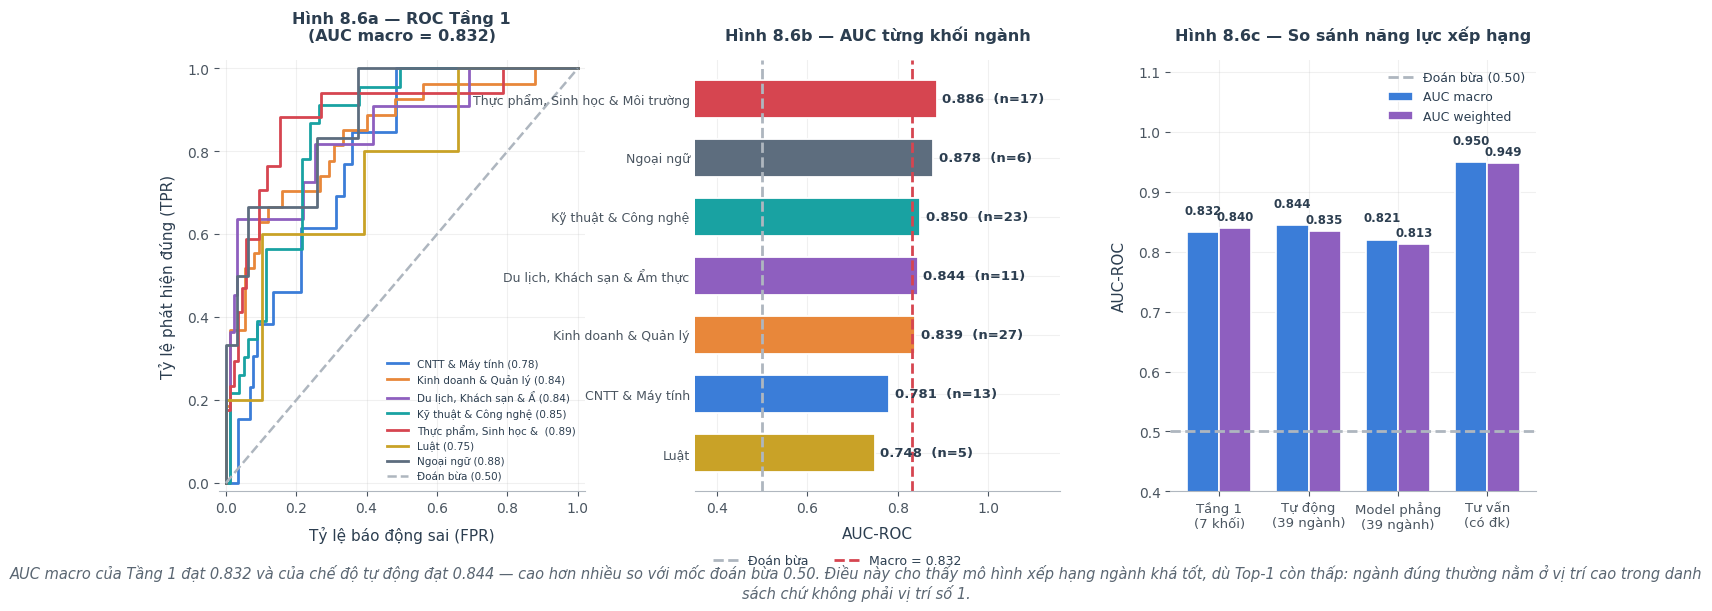

In [17]:
# ═══════════ HÌNH 8.6 — Đường ROC và AUC ═══════════
fig = plt.figure(figsize=(17, 5.6))
gs = fig.add_gridspec(1, 3, wspace=0.3)

# (a) ROC one-vs-rest cho 7 khối ngành
ax = fig.add_subplot(gs[0, 0])
y_bin = np.stack([(y_te_k == i).astype(int) for i in range(7)], axis=1)
for i in range(7):
    if i not in auc_khoi:
        continue
    fpr, tpr, _ = roc_curve(y_bin[:, i], P1_te[:, i])
    ax.plot(fpr, tpr, lw=2, color=C_KHOI[i],
            label=f"{TEN_KHOI[i][:22]} ({auc_khoi[i]:.2f})")
ax.plot([0, 1], [0, 1], "--", lw=1.8, color=C_XAM, label="Đoán bừa (0.50)")
ax.set_xlabel("Tỷ lệ báo động sai (FPR)"); ax.set_ylabel("Tỷ lệ phát hiện đúng (TPR)")
ax.set_title(f"Hình 8.6a — ROC Tầng 1\n(AUC macro = {AUC_S1_MAC:.3f})", fontsize=11.5)
ax.legend(fontsize=7.5, loc="lower right"); ax.set_axisbelow(True)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

# (b) AUC từng khối ngành
ax = fig.add_subplot(gs[0, 1])
kh = sorted(auc_khoi, key=lambda i: auc_khoi[i])
gt = [auc_khoi[i] for i in kh]
ax.barh(range(len(kh)), gt, height=0.64, color=[C_KHOI[i] for i in kh],
        edgecolor="white", linewidth=1.3)
ax.axvline(0.5, color=C_XAM, ls="--", lw=2, label="Đoán bừa")
ax.axvline(AUC_S1_MAC, color=C_THAT, ls="--", lw=2, label=f"Macro = {AUC_S1_MAC:.3f}")
for j, i in enumerate(kh):
    n_i = int((y_te_k == i).sum())
    ax.text(gt[j] + 0.012, j, f"{gt[j]:.3f}  (n={n_i})", va="center", fontsize=9.5,
            fontweight="bold", color=C_DAM)
ax.set_yticks(range(len(kh))); ax.set_yticklabels([TEN_KHOI[i] for i in kh], fontsize=9)
ax.set_xlabel("AUC-ROC"); ax.set_xlim(0.35, 1.16)
ax.set_title("Hình 8.6b — AUC từng khối ngành", fontsize=11.5)
ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(0.02, -0.12), ncol=2)
ax.tick_params(axis="y", length=0)
ax.set_axisbelow(True)

# (c) So sánh AUC giữa các phương án
ax = fig.add_subplot(gs[0, 2])
ten_pa = ["Tầng 1\n(7 khối)", "Tự động\n(39 ngành)", "Model phẳng\n(39 ngành)", "Tư vấn\n(có đk)"]
v_mac = [AUC_S1_MAC, AUC_AUTO_MAC, AUC_PHANG_MAC, AUC_TV_MAC]
v_wei = [AUC_S1_WEI, AUC_AUTO_WEI, AUC_PHANG_WEI, AUC_TV_WEI]
x = np.arange(4); w = 0.36
b1 = ax.bar(x - w/2, v_mac, w, label="AUC macro", color=C_XANH, edgecolor="white", linewidth=1.2)
b2 = ax.bar(x + w/2, v_wei, w, label="AUC weighted", color=C_TIM, edgecolor="white", linewidth=1.2)
for b, dy in list(zip(b1, [0.030] * 4)) + list(zip(b2, [0.012] * 4)):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + dy, f"{b.get_height():.3f}",
            ha="center", fontsize=8.5, fontweight="bold")
ax.axhline(0.5, color=C_XAM, ls="--", lw=2, label="Đoán bừa (0.50)")
ax.set_xticks(x); ax.set_xticklabels(ten_pa, fontsize=9.5)
ax.set_ylabel("AUC-ROC"); ax.set_ylim(0.4, 1.12)
ax.set_title("Hình 8.6c — So sánh năng lực xếp hạng", fontsize=11.5)
ax.legend(fontsize=9); ax.set_axisbelow(True)

luu(fig, OUTPUT_DIR, "hinh_8_6_duong_roc_va_auc.png",
    f"AUC macro của Tầng 1 đạt {AUC_S1_MAC:.3f} và của chế độ tự động đạt {AUC_AUTO_MAC:.3f} — "
    "cao hơn nhiều so với mốc đoán bừa 0.50. Điều này cho thấy mô hình xếp hạng ngành khá tốt, "
    "dù Top-1 còn thấp: ngành đúng thường nằm ở vị trí cao trong danh sách chứ không phải vị trí số 1.")
plt.show()

   💾 Đã lưu hình: hinh_8_7_tong_hop_chi_so.png


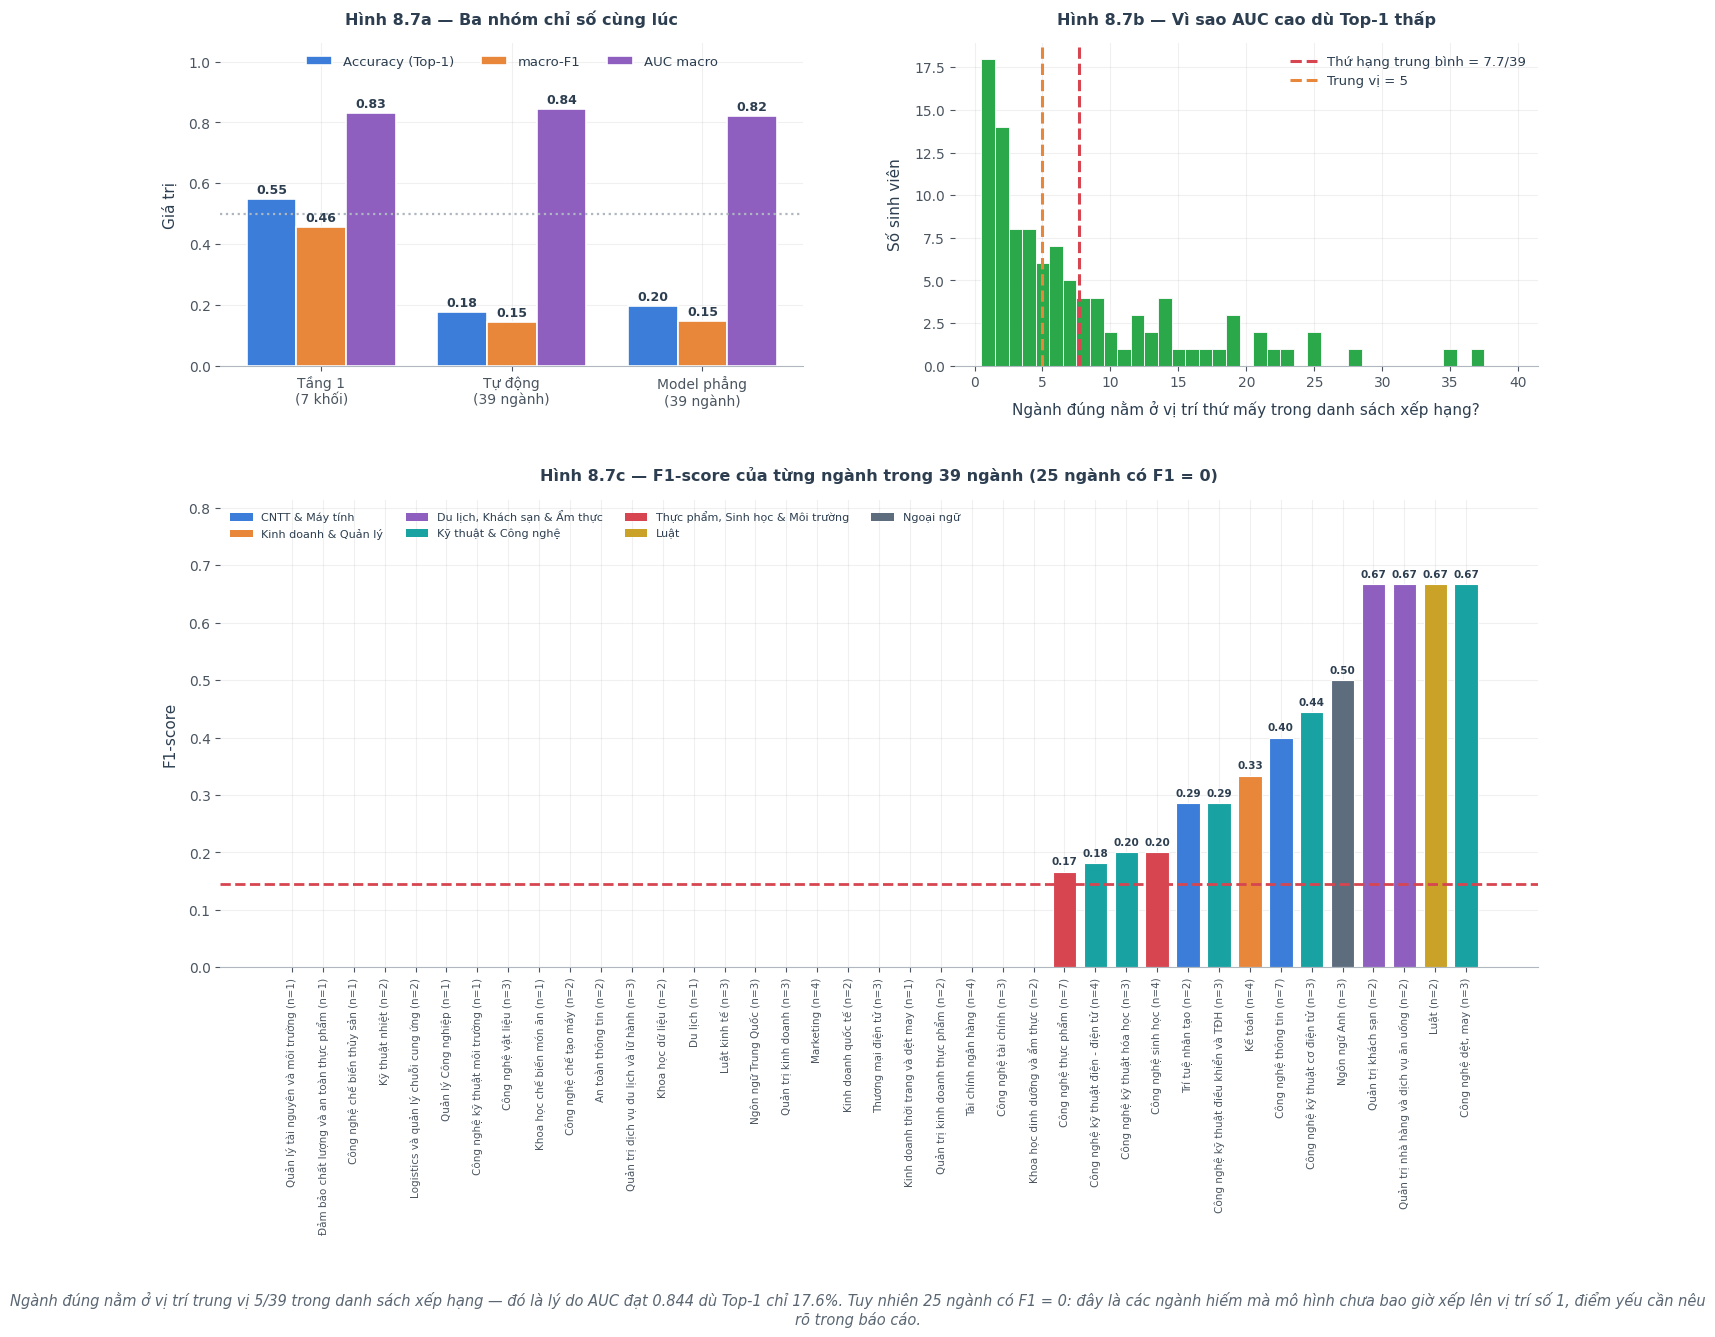

In [18]:
# ═══════════ HÌNH 8.7 — Tổng hợp Accuracy · F1 · AUC ═══════════
fig = plt.figure(figsize=(17, 12))
gs = fig.add_gridspec(2, 2, hspace=0.34, wspace=0.26, height_ratios=[1, 1.45])

# (a) Ba nhóm chỉ số cạnh nhau
ax = fig.add_subplot(gs[0, 0])
pa = ["Tầng 1\n(7 khối)", "Tự động\n(39 ngành)", "Model phẳng\n(39 ngành)"]
bo_cs = [("Accuracy (Top-1)", C_XANH), ("macro-F1", C_CAM), ("AUC macro", C_TIM)]
x = np.arange(3); w = 0.26
for i, (cs, mau) in enumerate(bo_cs):
    v = [BANG_CHI_SO.iloc[j][cs] for j in [0, 1, 2]]
    b = ax.bar(x + (i - 1) * w, v, w, label=cs, color=mau, edgecolor="white", linewidth=1.2)
    for bb, vv in zip(b, v):
        ax.text(bb.get_x() + bb.get_width()/2, vv + 0.018, f"{vv:.2f}",
                ha="center", fontsize=9, fontweight="bold")
ax.axhline(0.5, color=C_XAM, ls=":", lw=1.6)
ax.set_xticks(x); ax.set_xticklabels(pa, fontsize=10)
ax.set_ylabel("Giá trị"); ax.set_ylim(0, 1.06)
ax.set_title("Hình 8.7a — Ba nhóm chỉ số cùng lúc", fontsize=11.5)
ax.legend(fontsize=9.5, ncol=3, loc="upper center"); ax.set_axisbelow(True)

# (b) Vì sao Accuracy thấp mà AUC cao
ax = fig.add_subplot(gs[0, 1])
thu_hang = np.array([int(np.where(np.argsort(-P_auto[i]) == y_te_n[i])[0][0]) + 1
                     for i in range(len(y_te_n))])
ax.hist(thu_hang, bins=np.arange(0.5, 40.5, 1), color=C_GA, edgecolor="white", linewidth=0.6)
ax.axvline(thu_hang.mean(), color=C_THAT, ls="--", lw=2.2,
           label=f"Thứ hạng trung bình = {thu_hang.mean():.1f}/39")
ax.axvline(np.median(thu_hang), color=C_CAM, ls="--", lw=2.2,
           label=f"Trung vị = {np.median(thu_hang):.0f}")
ax.set_xlabel("Ngành đúng nằm ở vị trí thứ mấy trong danh sách xếp hạng?")
ax.set_ylabel("Số sinh viên")
ax.set_title("Hình 8.7b — Vì sao AUC cao dù Top-1 thấp", fontsize=11.5)
ax.legend(fontsize=9.5); ax.set_axisbelow(True)

# (c) F1 từng ngành (39 lớp)
ax = fig.add_subplot(gs[1, :])
pr, rc, f1_ng, sup_ng = precision_recall_fscore_support(
    y_te_n, P_auto.argmax(1), labels=range(39), zero_division=0)
thu_tu = np.argsort(f1_ng)
mau_ng = [C_KHOI[int(LB["idx_to_khoi"][str(i)])] for i in thu_tu]
ax.bar(range(39), f1_ng[thu_tu], color=mau_ng, edgecolor="white", linewidth=0.8, width=0.76)
ax.axhline(KQ["auto"]["macro_f1"], color=C_THAT, ls="--", lw=2,
           label=f"macro-F1 = {KQ['auto']['macro_f1']:.3f}")
for j, i in enumerate(thu_tu):
    if f1_ng[i] > 0:
        ax.text(j, f1_ng[i] + 0.012, f"{f1_ng[i]:.2f}", ha="center", fontsize=7.5,
                fontweight="bold", color=C_DAM)
ax.set_xticks(range(39))
ax.set_xticklabels([f"{TEN_NGANH[i]} (n={int(sup_ng[i])})" for i in thu_tu],
                   rotation=90, fontsize=7.5)
ax.set_ylabel("F1-score"); ax.set_ylim(0, max(f1_ng) * 1.22 if max(f1_ng) > 0 else 1)
n_khong = int((f1_ng == 0).sum())
ax.set_title(f"Hình 8.7c — F1-score của từng ngành trong 39 ngành "
             f"({n_khong} ngành có F1 = 0)", fontsize=11.5)
ax.legend(handles=[Patch(facecolor=C_KHOI[i], label=TEN_KHOI[i]) for i in range(7)],
          ncol=4, fontsize=8, loc="upper left")
ax.set_axisbelow(True)

chu_thich(fig,
    f"Ngành đúng nằm ở vị trí trung vị {np.median(thu_hang):.0f}/39 trong danh sách xếp hạng — "
    f"đó là lý do AUC đạt {AUC_AUTO_MAC:.3f} dù Top-1 chỉ {KQ['auto']['top1']:.1%}. "
    f"Tuy nhiên {n_khong} ngành có F1 = 0: đây là các ngành hiếm mà mô hình chưa bao giờ "
    "xếp lên vị trí số 1, điểm yếu cần nêu rõ trong báo cáo.", y=-0.16)
luu(fig, OUTPUT_DIR, "hinh_8_7_tong_hop_chi_so.png")
plt.show()

In [19]:
# --- Xuất kết quả -------------------------------------------------------------
pd.DataFrame([{"fold": c["fold"],
               **{f"khoi_{kk}": v for kk, v in do_luong(c["yk"], c["P1"], ks=(1, 2, 3)).items()},
               **{f"auto_{kk}": v for kk, v in
                  do_luong(c["yn"], gop_2_tang(c["P1"], c["P2"], BETA)).items()}}
              for c in CACHE]).to_csv(OUTPUT_DIR / "cv_results.csv", index=False)
bang_cv.to_csv(OUTPUT_DIR / "so_sanh_kien_truc_cv.csv", encoding="utf-8-sig")
df_abl.to_csv(OUTPUT_DIR / "ablation_du_lieu_tong_hop.csv", index=False, encoding="utf-8-sig")

tom_tat = {
    "ngay_chay": time.strftime("%Y-%m-%d %H:%M"), "seed": SEED,
    "du_lieu": {"train_that": int(N_REAL), "train_tong_hop": int(len(X_syn_base)),
                "test_that": int(len(y_te_n)), "n_dac_trung": int(X_train.shape[1]),
                "n_lop_nganh": 39, "n_lop_khoi": 7},
    "cv": {"n_splits": CV["n_splits"], "n_repeats": CV["n_repeats"],
           "ghi_chu": "VAL chỉ gồm dòng thật; dòng tổng hợp chỉ vào TRAIN và sinh riêng theo fold"},
    "sieu_tham_so": {"tang1": P_S1, "tang2": P_S2, "beta": BETA},
    "cv_macro_f1": {kk: float(v) for kk, v in bang_cv["macro_f1"].items()},
    "cv_overfit": {"train_top1": float(acc_tr), "val_top1": float(acc_va)},
    "test": {"tang1_khoi": KQ["tang1_khoi"],
             "auto_CHI_SO_CHINH": KQ["auto"],
             "phang_39_doi_chung": KQ["phang"],
             "tu_van_CO_DIEU_KIEN": KQ["tu_van"]},
    "baseline": {"khoi_top1": float(BASE["khoi_top1"]), "nganh_top1": float(BASE["nganh_top1"]),
                 "nganh_top3": float(BASE["nganh_top3"]), "nganh_top5": float(BASE["nganh_top5"])},
    "ablation_tong_hop_co_ich": bool(HUU_ICH),
    "auc_roc": {"tang1_macro": float(AUC_S1_MAC), "tang1_weighted": float(AUC_S1_WEI),
                "auto_macro": float(AUC_AUTO_MAC), "auto_weighted": float(AUC_AUTO_WEI),
                "phang_macro": float(AUC_PHANG_MAC), "tu_van_macro": float(AUC_TV_MAC),
                "tang1_tung_khoi": {TEN_KHOI[i]: float(v) for i, v in auc_khoi.items()}},
    "dong_gop_nhom_dac_trung": {k: {kk: float(vv) for kk, vv in v.items()}
                                for k, v in kq_nhom.items()},
    "dong_gop_rieng_cua_likert": DONG_GOP_LIKERT,
    "canh_bao": ("Chỉ số hệ thống là 'auto'. 'tu_van' giả định người dùng chọn ĐÚNG khối ngành "
                 "nên không phải năng lực tự động của mô hình."),
}
json.dump(tom_tat, open(OUTPUT_DIR / "metrics_summary.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)

print("═" * 70)
print("  TÓM TẮT GIAI ĐOẠN 8")
print("═" * 70)
print(f"  Tầng 1 — khối ngành Top-1     {KQ['tang1_khoi']['top1']:>10.1%}")
print(f"  Tự động — ngành Top-1         {KQ['auto']['top1']:>10.1%}")
print(f"  Tự động — ngành Top-3         {KQ['auto']['top3']:>10.1%}   ← chỉ số chính")
print(f"  Tự động — ngành Top-5         {KQ['auto']['top5']:>10.1%}")
print(f"  Tư vấn  — ngành Top-3         {KQ['tu_van']['top3']:>10.1%}   (có điều kiện)")
print(f"  β của cơ chế 2 tầng           {BETA:>10.1f}")
print(f"  Dữ liệu tổng hợp có ích       {'CÓ' if HUU_ICH else 'KHÔNG':>10}")
print(f"  10 câu Likert đóng góp Top-3  {DONG_GOP_LIKERT['top3']:>+10.1%}")
print(f"  AUC-ROC macro — Tầng 1        {AUC_S1_MAC:>10.3f}")
print(f"  AUC-ROC macro — Tự động       {AUC_AUTO_MAC:>10.3f}")
print("═" * 70)
print("\n  Tệp xuất:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"     {f.name:<42}{f.stat().st_size/1024:>9,.0f} KB")
print("\n  Việc tiếp theo: notebook 09 — giải thích dự đoán bằng TreeSHAP (chưa nằm trong đợt này).")

══════════════════════════════════════════════════════════════════════
  TÓM TẮT GIAI ĐOẠN 8
══════════════════════════════════════════════════════════════════════
  Tầng 1 — khối ngành Top-1          54.9%
  Tự động — ngành Top-1              17.6%
  Tự động — ngành Top-3              39.2%   ← chỉ số chính
  Tự động — ngành Top-5              52.9%
  Tư vấn  — ngành Top-3              69.6%   (có điều kiện)
  β của cơ chế 2 tầng                  0.6
  Dữ liệu tổng hợp có ích               CÓ
  10 câu Likert đóng góp Top-3      +10.4%
  AUC-ROC macro — Tầng 1             0.832
  AUC-ROC macro — Tự động            0.844
══════════════════════════════════════════════════════════════════════

  Tệp xuất:
     ablation_du_lieu_tong_hop.csv                     0 KB
     ablation_nhom_dac_trung.csv                       1 KB
     classification_report_stage1.csv                  1 KB
     cv_results.csv                                    3 KB
     hinh_8_1_tim_sieu_tham_so.png              